# Linear Programming — Formulation and Graphical Solution

**An interactive companion to the lecture by Dr. Islam Ali**

---

This notebook walks through the whole lecture, but every idea is something you can *run*:
drag a slider, change a coefficient, watch the feasible region move.

| Part | Topic |
|---|---|
| 0 | Setup |
| 1 | What a linear program is |
| 2 | Formulating LP problems (7 worked examples, all interactive) |
| 3 | The graphical solution method (iso-profit line + corner point) |
| 4 | Irregular LPs: multiple optima, infeasible, unbounded |
| 5 | A reusable LP toolkit — parser, solver, plotter |
| 6 | **The solver:** feed it an `.lp` file, get the graphical solution |
| 7 | Exercises |

> **How to use:** run the cells top to bottom (`Shift+Enter`). Part 0 installs what is
> missing. If `ipywidgets` is unavailable the interactive cells still run — they just
> fall back to plain function calls you can edit by hand.

## Part 0 — Setup

`numpy` and `matplotlib` are required; `ipywidgets` and `pandas` are optional but make the
notebook much nicer. `scipy` is used only for the infeasible/unbounded diagnostics.

In [1]:
# Run once. Safe to re-run.
import sys, subprocess, importlib

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        return True
    except ImportError:
        print(f"installing {pkg} ...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
            importlib.invalidate_caches()
            importlib.import_module(name)
            return True
        except Exception as e:
            print(f"  could not install {pkg}: {e}")
            return False

for p in ["numpy", "matplotlib", "scipy", "pandas", "ipywidgets"]:
    ensure(p)

installing numpy ...
installing matplotlib ...
installing scipy ...
installing pandas ...
installing ipywidgets ...


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

plt.rcParams.update({
    "figure.figsize": (8, 6.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "font.size": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
})

# --- an `interact` that degrades gracefully -------------------------------
try:
    from ipywidgets import interact, interactive, FloatSlider, IntSlider, \
                           Dropdown, Textarea, Button, Output, VBox, HBox, Layout
    from IPython.display import display, Markdown, HTML
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    from IPython.display import display, Markdown, HTML

    def interact(_f=None, **kwargs):
        """Fallback: call the function once with the default of each control."""
        def wrap(f):
            defaults = {}
            for k, v in kwargs.items():
                if isinstance(v, tuple):
                    defaults[k] = v[0] if len(v) < 3 else v[0]
                elif isinstance(v, list):
                    defaults[k] = v[0]
                else:
                    defaults[k] = getattr(v, "value", v)
            print("[ipywidgets not available — showing the default case; "
                  "edit the arguments and re-run to explore]")
            f(**defaults)
            return f
        return wrap(_f) if _f is not None else wrap

print("setup complete —", "widgets ON" if HAS_WIDGETS else "widgets OFF (static mode)")

setup complete — widgets ON


---
## Part 1 — What is a Linear Program?

A **linear program (LP)** is a model in which we choose the values of some *decision
variables* so as to make a *linear objective function* as large (or as small) as possible,
while respecting a set of *linear constraints*.

Every LP model has exactly four ingredients:

| Ingredient | What it is | Example |
|---|---|---|
| **Decision variables** | the quantities you control | $x_1$ = number of bowls produced per day |
| **Objective function** | the single linear measure you want to maximise or minimise | $Z = 40x_1 + 50x_2$ (profit) |
| **Constraints** | linear limits on the resources or requirements | $1x_1 + 2x_2 \le 40$ hours of labour |
| **Non-negativity** | you cannot produce a negative amount | $x_1 \ge 0,\; x_2 \ge 0$ |

The general form with two variables:

$$
\begin{aligned}
\text{Maximise (or Minimise)}\quad & Z = c_1x_1 + c_2x_2 \\
\text{subject to}\quad & a_{11}x_1 + a_{12}x_2 \;\{\le,=,\ge\}\; b_1\\
& a_{21}x_1 + a_{22}x_2 \;\{\le,=,\ge\}\; b_2\\
& \vdots\\
& x_1,\;x_2 \ge 0
\end{aligned}
$$

**"Linear"** means two things, and both matter:

1. *Proportionality* — doubling $x_1$ doubles its contribution to profit and to every
   resource it consumes. No volume discounts, no economies of scale.
2. *Additivity* — the total is the sum of the parts. No interaction terms such as
   $x_1x_2$, no powers such as $x_1^2$.

Two further standing assumptions: **divisibility** (fractional values are allowed — if they
are not, the problem becomes *integer* programming) and **certainty** (all the $c$'s,
$a$'s and $b$'s are known constants).

---
## Part 2 — Formulating LP Problems

Formulation is the hard part; once a problem is written down correctly, solving it is
mechanical. The routine is always the same:

1. Read the problem and ask **"what am I being asked to decide?"** → decision variables.
2. Ask **"what is being maximised or minimised?"** → objective function.
3. Ask **"what limits me?"** (resources: usually $\le$) and **"what is required of me?"**
   (requirements: usually $\ge$) → constraints.
4. Add non-negativity.

A habit worth building: **check the units of every constraint.** If the left-hand side is in
hours, the right-hand side must be in hours too. Most formulation errors show up
immediately as a units mismatch.

### 2.1 The product-mix problem — an electronics manufacturer

An electronics manufacturer makes two products, a **DVD player** and a **mobile phone**.
We want the mix of products that produces the maximum profit.

| | Electronic time (hr/unit) | Assembly time (hr/unit) | Profit ($/unit) |
|---|---|---|---|
| DVD player  | 4 | 2 | 7 |
| Mobile phone| 3 | 1 | 5 |
| **Available** | **240 hr** | **100 hr** | |

**Decision variables**

$$x_1 = \text{number of DVD players to be produced},\qquad
  x_2 = \text{number of mobile phones to be produced}$$

**Objective function**

$$\text{Maximise Profit } Z = 7x_1 + 5x_2$$

**Constraints**

$$
\begin{aligned}
4x_1 + 3x_2 &\le 240 &&\text{(hours of electronic time)}\\
2x_1 + 1x_2 &\le 100 &&\text{(hours of assembly time)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

Read the first constraint back in words: *each DVD player eats 4 hours of electronic time
and each phone eats 3; together they may not exceed the 240 hours available.*

In [3]:
# --- interactive: try a production plan and see what it costs you -----------
def electronics_plan(x1=30, x2=40):
    elec, asm = 4*x1 + 3*x2, 2*x1 + 1*x2
    profit = 7*x1 + 5*x2
    rows = [("Electronic time", elec, 240), ("Assembly time", asm, 100)]
    print(f"Plan: {x1:g} DVD players, {x2:g} mobile phones")
    print(f"Profit  Z = 7({x1:g}) + 5({x2:g}) = ${profit:,.0f}\n")
    ok = True
    for name, used, avail in rows:
        slack = avail - used
        flag = "OK  " if slack >= 0 else "VIOLATED"
        ok &= slack >= 0
        print(f"  {name:<16} used {used:7.1f} / {avail:5.0f}   "
              f"slack {slack:7.1f}   {flag}")
    print("\n=> FEASIBLE plan" if ok else "\n=> INFEASIBLE plan")

interact(electronics_plan,
         x1=(0, 60, 1),
         x2=(0, 90, 1));

interactive(children=(IntSlider(value=30, description='x1', max=60), IntSlider(value=40, description='x2', max…

### 2.2 Beaver Creek Pottery Company — a maximisation example

A pottery makes **bowls** and **mugs** from two resources, **labour** and **clay**.

| Product | Labour (hr/unit) | Clay (lb/unit) | Profit ($/unit) |
|---|---|---|---|
| Bowl | 1 | 4 | 40 |
| Mug  | 2 | 3 | 50 |
| **Resource availability** | **40 hr/day** | **120 lb** | |

**Decision variables**

$$x_1 = \text{bowls produced per day},\qquad x_2 = \text{mugs produced per day}$$

**Complete model**

$$
\begin{aligned}
\text{Maximise } Z &= 40x_1 + 50x_2 &&\text{(profit per day)}\\
\text{subject to } \quad 1x_1 + 2x_2 &\le 40 &&\text{(hours of labour)}\\
4x_1 + 3x_2 &\le 120 &&\text{(pounds of clay)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

> **Watch the coefficients.** The labour row of the table reads *down* the "Labour" column:
> a bowl needs 1 hour, a mug needs 2, so the labour constraint is $1x_1 + 2x_2 \le 40$.
> A very common slip is to read *across* a row instead and write $1x_1 + 4x_2$.

#### Feasible and infeasible solutions

A **feasible solution** violates none of the constraints. An **infeasible solution**
violates at least one.

*From the lecture:*

- $x_1 = 5,\; x_2 = 10$: $Z = 40(5) + 50(10) = \$700$.
  Labour $1(5)+2(10) = 25 \le 40$ ✓, clay $4(5)+3(10) = 70 \le 120$ ✓ → **feasible**.
- $x_1 = 10,\; x_2 = 20$: $Z = \$1400$.
  Labour $1(10)+2(20) = 50 > 40$ ✗ → **infeasible**, however attractive the profit looks.

That second example is the whole point of LP: the profit number alone tells you nothing
until you have checked that the plan can actually be carried out.

In [4]:
# --- interactive: feasibility checker with a live picture -------------------
def pottery_point(x1=5, x2=10):
    labour, clay = 1*x1 + 2*x2, 4*x1 + 3*x2
    Z = 40*x1 + 50*x2
    feas = labour <= 40 and clay <= 120 and x1 >= 0 and x2 >= 0

    fig, ax = plt.subplots()
    xs = np.linspace(0, 45, 400)
    ax.plot(xs, (40 - xs)/2,   lw=2, label="labour: $x_1 + 2x_2 \\leq 40$")
    ax.plot(xs, (120 - 4*xs)/3, lw=2, label="clay: $4x_1 + 3x_2 \\leq 120$")
    # feasible region
    X, Y = np.meshgrid(np.linspace(0, 45, 400), np.linspace(0, 45, 400))
    m = (X + 2*Y <= 40) & (4*X + 3*Y <= 120) & (X >= 0) & (Y >= 0)
    ax.contourf(X, Y, m.astype(float), levels=[.5, 1.5], colors=["#7ba7d7"], alpha=.35)
    ax.plot(x1, x2, "*", ms=22, color=("#2a9d8f" if feas else "#d1495b"),
            mec="k", mew=.6, zorder=5)
    ax.set_xlim(0, 45); ax.set_ylim(0, 45)
    ax.set_xlabel("$x_1$  (bowls)"); ax.set_ylabel("$x_2$  (mugs)")
    ax.set_title(f"({x1:g}, {x2:g})   Z = ${Z:,.0f}   "
                 f"{'FEASIBLE' if feas else 'INFEASIBLE'}")
    ax.legend(loc="upper right")
    plt.show()

    print(f"labour: 1({x1:g}) + 2({x2:g}) = {labour:g}  {'<=' if labour<=40 else '>'} 40"
          f"   {'ok' if labour<=40 else 'VIOLATED'}")
    print(f"clay  : 4({x1:g}) + 3({x2:g}) = {clay:g}  {'<=' if clay<=120 else '>'} 120"
          f"  {'ok' if clay<=120 else 'VIOLATED'}")
    print(f"Z = 40({x1:g}) + 50({x2:g}) = ${Z:,.0f}")

interact(pottery_point, x1=(0, 45, 1), x2=(0, 45, 1));

interactive(children=(IntSlider(value=5, description='x1', max=45), IntSlider(value=10, description='x2', max=…

### 2.3 A minimisation example — photo-developing chemicals

A chemicals manufacturer produces two photo-developing fluids:

* a **black-and-white** picture chemical costing **\$2,500 per ton**,
* a **colour** photo chemical costing **\$3,000 per ton**.

From current inventory and outstanding orders: at least **30 tons** of the black-and-white
chemical and at least **20 tons** of the colour chemical must be produced next month.
Both chemicals must be used within the month, so to avoid wasting expensive raw material
at least **60 tons** of photo chemicals in total must be produced.

Determine the amount of each chemical that minimises total cost.

**Decision variables**

$$x_1 = \text{tons of black-and-white chemical},\qquad x_2 = \text{tons of colour chemical}$$

**Model**

$$
\begin{aligned}
\text{Minimise } Z &= 2500x_1 + 3000x_2\\
\text{subject to}\quad x_1 &\ge 30 &&\text{(b\&w requirement)}\\
x_2 &\ge 20 &&\text{(colour requirement)}\\
x_1 + x_2 &\ge 60 &&\text{(total tonnage)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

Notice the change of character: this is a **requirements** problem, so the constraints point
the other way ($\ge$) and the feasible region is unbounded *above* — but the objective is a
cost we are pushing *down*, so an optimum still exists. We solve it graphically in Part 3.

In [5]:
def chem_plan(x1=40, x2=20):
    cost = 2500*x1 + 3000*x2
    checks = [("x1 >= 30", x1, 30, x1 >= 30),
              ("x2 >= 20", x2, 20, x2 >= 20),
              ("x1 + x2 >= 60", x1 + x2, 60, x1 + x2 >= 60)]
    print(f"Produce {x1:g} t b&w and {x2:g} t colour  ->  cost = ${cost:,.0f}\n")
    for label, lhs, rhs, ok in checks:
        print(f"  {label:<16} {lhs:7.1f} vs {rhs:5.0f}   {'ok' if ok else 'VIOLATED'}")
    print("\n=> FEASIBLE" if all(c[3] for c in checks) else "\n=> INFEASIBLE")

interact(chem_plan, x1=(0, 90, 1), x2=(0, 90, 1));

interactive(children=(IntSlider(value=40, description='x1', max=90), IntSlider(value=20, description='x2', max…

### 2.4 An airline scheduling problem

A local airline is considering service from its US hub to **Rome** and **Dublin**.

* One gate at the US airport, open **12 hours per day**; each flight needs 1 hour of gate time.
* Each Rome flight uses **15 hours** of pilot-crew time and earns **\$2,500** profit.
* Each Dublin flight uses **10 hours** of pilot-crew time and earns **\$2,000** profit.
* Pilot-crew labour is limited to **150 hours per day**.
* The market for Rome service is limited to **9 flights per day**.

**Model**

$$
\begin{aligned}
\text{Maximise } Z &= 2500x_1 + 2000x_2\\
\text{subject to}\quad x_1 + x_2 &\le 12 &&\text{(gate capacity)}\\
15x_1 + 10x_2 &\le 150 &&\text{(crew labour)}\\
x_1 &\le 9 &&\text{(market)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

where $x_1$ = daily flights to Rome, $x_2$ = daily flights to Dublin.

The gate constraint is $x_1 + x_2 \le 12$ because *each* flight consumes one of the
12 available gate-hours — the coefficient is 1 for both destinations even though the flights
are very different in every other respect.

### 2.5 A minimisation example — fertilizer

Two brands of fertilizer are available, **Super-Gro** and **Crop-Quick**. A field requires at
least **16 pounds of nitrogen** and at least **24 pounds of phosphate**.

| Brand | Nitrogen (lb/bag) | Phosphate (lb/bag) | Cost ($/bag) |
|---|---|---|---|
| Super-Gro  | 2 | 4 | 6 |
| Crop-Quick | 4 | 3 | 3 |

**Model** — $x_1$ = bags of Super-Gro, $x_2$ = bags of Crop-Quick

$$
\begin{aligned}
\text{Minimise } Z &= 6x_1 + 3x_2\\
\text{subject to}\quad 2x_1 + 4x_2 &\ge 16 &&\text{(nitrogen)}\\
4x_1 + 3x_2 &\ge 24 &&\text{(phosphate)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

### 2.6 A blending example — the hot-dog mixture

Hot-dog mixture is made in **1-ton (1,000 kg) batches** from two ingredients,
**chicken (\$3/kg)** and **beef (\$5/kg)**. The recipe requires

* at least **500 kg** of chicken,
* at least **200 kg** of beef,
* a ratio of chicken to beef of **at least 2 to 1**.

**Decision variables** — $x_1$ = kg of chicken, $x_2$ = kg of beef.

**Model**

$$
\begin{aligned}
\text{Minimise } Z &= 3x_1 + 5x_2\\
\text{subject to}\quad x_1 + x_2 &= 1000 &&\text{(batch size — an equality!)}\\
x_1 &\ge 500 &&\text{(chicken minimum)}\\
x_2 &\ge 200 &&\text{(beef minimum)}\\
\tfrac{x_1}{x_2} &\ge \tfrac{2}{1} \;\Longleftrightarrow\; x_1 - 2x_2 \ge 0
&&\text{(ratio)}\\
x_1, x_2 &\ge 0
\end{aligned}
$$

**The ratio trick is worth memorising.** $\dfrac{x_1}{x_2} \ge 2$ is *not* linear as written.
Multiply both sides by $x_2$ (legitimate because $x_2 \ge 0$) to get $x_1 \ge 2x_2$, then move
everything to one side: $x_1 - 2x_2 \ge 0$. Any "at least $p$ parts to $q$ parts" requirement
becomes $qx_1 - px_2 \ge 0$ in the same way.

Note also the **equality** constraint — the batch must be exactly one ton. Equalities are
perfectly legal in an LP; graphically they collapse the feasible region onto a *line segment*
rather than an area.

In [6]:
# --- ratio constraint: linear or not? ---------------------------------------
def ratio_demo(x2=250):
    x1 = 1000 - x2                      # batch equality
    ratio = x1 / x2 if x2 else np.inf
    lin = x1 - 2*x2
    cost = 3*x1 + 5*x2
    print(f"beef x2 = {x2:6.1f} kg  ->  chicken x1 = {x1:6.1f} kg")
    print(f"  ratio x1/x2      = {ratio:6.3f}   (needs >= 2)")
    print(f"  linear form x1-2x2 = {lin:8.1f}   (needs >= 0)")
    print(f"  x1 >= 500 : {'ok' if x1 >= 500 else 'VIOLATED'}")
    print(f"  x2 >= 200 : {'ok' if x2 >= 200 else 'VIOLATED'}")
    ok = ratio >= 2 and x1 >= 500 and x2 >= 200
    print(f"  cost = 3({x1:.0f}) + 5({x2:.0f}) = ${cost:,.0f}   "
          f"{'FEASIBLE' if ok else 'INFEASIBLE'}")

interact(ratio_demo, x2=(50, 500, 10));

interactive(children=(IntSlider(value=250, description='x2', max=500, min=50, step=10), Output()), _dom_classe…

### 2.7 Formulation drill

Before moving on, try to write each of these down without looking, then check against the
models above.

1. A resource is available in limited supply → which way does the inequality point?
2. A nutritional / contractual *requirement* → which way now?
3. "Exactly one ton per batch" → what kind of constraint?
4. "At least three times as many A as B" → write it in linear form.

<details>
<summary><b>Answers</b></summary>

1. $\le$ — you cannot use more than exists.
2. $\ge$ — you must meet or exceed the requirement.
3. An equality, $=$.
4. $x_A \ge 3x_B \Longleftrightarrow x_A - 3x_B \ge 0$.

</details>

---
## Part 3 — The Graphical Solution Method

The graphical method **can be used when there are exactly two decision variables** — with
two variables the solution space is a plane we can draw. The procedure:

1. **Plot the constraint equations at their limits** by converting each inequality to an
   equality. An equality in two variables is a straight line.
2. **Identify the feasible solution space** — the region satisfying *all* constraints
   simultaneously.
3. **Create an iso-profit (iso-cost) line** from the objective function.
4. **Move that line outwards** (for a maximisation) until it is about to leave the feasible
   region. The last point it touches is optimal.

We will use the electronics product-mix model throughout:

$$\text{Maximise } Z = 7x_1 + 5x_2 \quad\text{s.t.}\quad 4x_1+3x_2 \le 240,\;\; 2x_1+x_2 \le 100,\;\; x_1,x_2\ge0$$

### 3.1 Step 1 — plotting the constraint lines

Disregard the inequality part of the constraint ($\le$ or $\ge$). Making each constraint an
**equality** turns it into the equation of a straight line, and the fastest way to draw a
line is by its two **axis intercepts**:

For $4x_1 + 3x_2 = 240$:

* set $x_1 = 0 \Rightarrow x_2 = 80$ → the point $(0, 80)$
* set $x_2 = 0 \Rightarrow x_1 = 60$ → the point $(60, 0)$

For $2x_1 + x_2 = 100$: the intercepts are $(0, 100)$ and $(50, 0)$.

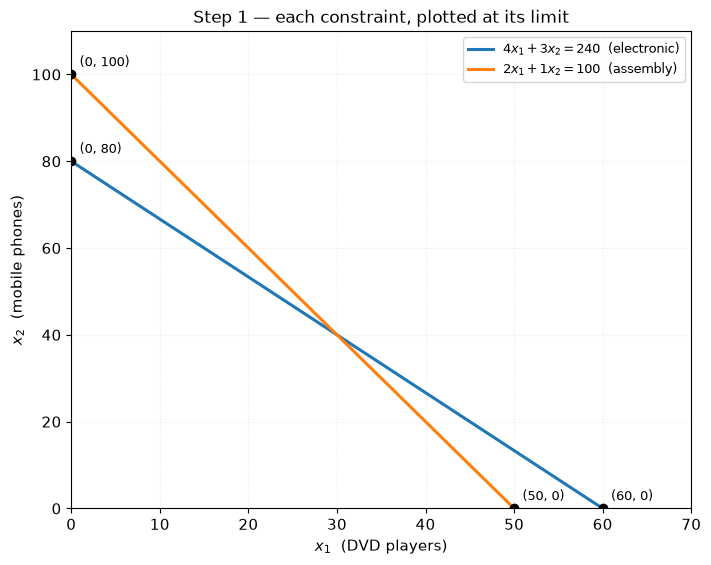

In [7]:
fig, ax = plt.subplots()
x = np.linspace(0, 70, 300)
ax.plot(x, (240 - 4*x)/3, lw=2.2, color="#1f77b4",
        label="$4x_1 + 3x_2 = 240$  (electronic)")
ax.plot(x, (100 - 2*x)/1, lw=2.2, color="#ff7f0e",
        label="$2x_1 + 1x_2 = 100$  (assembly)")
for (px, py), txt in [((0, 80), "(0, 80)"), ((60, 0), "(60, 0)"),
                      ((0, 100), "(0, 100)"), ((50, 0), "(50, 0)")]:
    ax.plot(px, py, "o", ms=6, color="k")
    ax.annotate(txt, (px, py), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlim(0, 70); ax.set_ylim(0, 110)
ax.set_xlabel("$x_1$  (DVD players)"); ax.set_ylabel("$x_2$  (mobile phones)")
ax.set_title("Step 1 — each constraint, plotted at its limit")
ax.legend(); plt.show()

### 3.2 Step 2 — the feasible region

The feasible region is the area of the graph containing the solutions that satisfy **all**
the constraints *simultaneously*. To find it, first locate the feasible side of each
constraint on its own, then take the area common to all of them.

**Which side is feasible?** Substitute a test point — the origin $(0,0)$ is easiest when it
is not on the line. For $4x_1+3x_2\le240$: $4(0)+3(0)=0\le240$ ✓, so the origin's side is
feasible.

The region below is the intersection of four half-planes: the two resource constraints plus
$x_1 \ge 0$ and $x_2 \ge 0$. It is a **convex polygon** — and that is the single most
important fact in this whole lecture, as the next step will show.

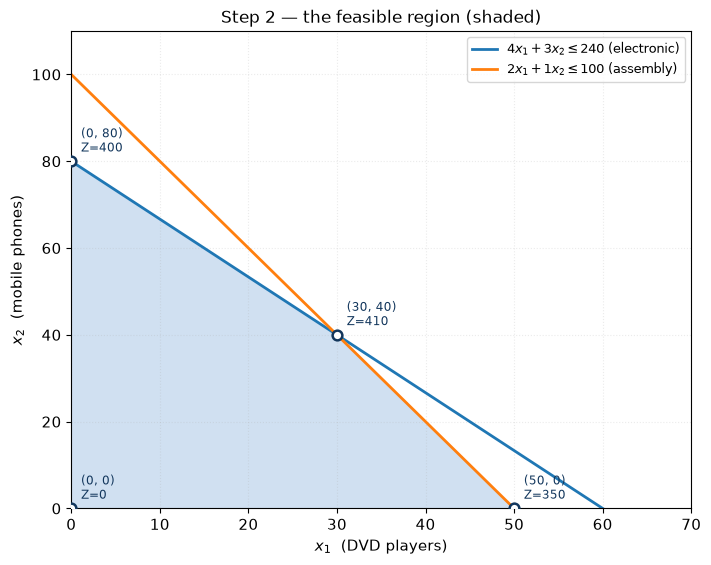

In [8]:
# A small reusable drawing helper we will use for the rest of Part 3.
def lp_draw(constraints, obj=None, sense="max", xlim=None, ylim=None,
            iso=None, corners=None, labels=("$x_1$", "$x_2$"),
            title="", highlight=None, ax=None, shade=True):
    """
    constraints : list of (a, b, op, c, label)  meaning  a*x1 + b*x2  op  c
    obj         : (c1, c2) or None
    iso         : list of Z values to draw as dashed iso-objective lines
    corners     : list of (x1, x2) points to mark
    highlight   : (x1, x2) optimal point to star
    """
    if ax is None:
        fig, ax = plt.subplots()
    xlim = xlim or (0, 10); ylim = ylim or (0, 10)
    xs = np.linspace(*xlim, 400)

    if shade:
        X, Y = np.meshgrid(np.linspace(*xlim, 500), np.linspace(*ylim, 500))
        m = (X >= -1e-9) & (Y >= -1e-9)
        for a, b, op, c, _ in constraints:
            lhs = a*X + b*Y
            m &= (lhs <= c + 1e-9) if op == "<=" else \
                 (lhs >= c - 1e-9) if op == ">=" else (np.abs(lhs - c) < 1e-2*max(xlim[1],1))
        ax.contourf(X, Y, m.astype(float), levels=[.5, 1.5],
                    colors=["#7ba7d7"], alpha=.35, zorder=0)

    for i, (a, b, op, c, lab) in enumerate(constraints):
        col = plt.cm.tab10(i % 10)
        if abs(b) > 1e-12:
            ax.plot(xs, (c - a*xs)/b, lw=2, color=col, label=lab)
        elif abs(a) > 1e-12:
            ax.axvline(c/a, lw=2, color=col, label=lab)

    if obj and iso:
        c1, c2 = obj
        for k, z in enumerate(iso):
            lab = "iso-objective lines" if k == 0 else None
            if abs(c2) > 1e-12:
                ax.plot(xs, (z - c1*xs)/c2, ls="--", lw=1.1, color="0.4", label=lab)
            else:
                ax.axvline(z/c1, ls="--", lw=1.1, color="0.4", label=lab)

    for p in (corners or []):
        ax.plot(*p, "o", ms=7, mfc="white", mec="#12365c", mew=1.8, zorder=5)
        z = f"\nZ={obj[0]*p[0]+obj[1]*p[1]:,.6g}" if obj else ""
        ax.annotate(f"({p[0]:g}, {p[1]:g}){z}", p, textcoords="offset points",
                    xytext=(7, 7), fontsize=8.5, color="#12365c")
    if highlight is not None:
        ax.plot(*highlight, "*", ms=22, color="#d1495b", mec="k", mew=.5, zorder=6)

    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1])
    ax.set_title(title); ax.legend(loc="upper right")
    return ax


ELEC = [(4, 3, "<=", 240, "$4x_1+3x_2 \\leq 240$ (electronic)"),
        (2, 1, "<=", 100, "$2x_1+1x_2 \\leq 100$ (assembly)")]

lp_draw(ELEC, obj=(7, 5), xlim=(0, 70), ylim=(0, 110),
        corners=[(0, 0), (0, 80), (30, 40), (50, 0)],
        labels=("$x_1$  (DVD players)", "$x_2$  (mobile phones)"),
        title="Step 2 — the feasible region (shaded)")
plt.show()

### 3.3 Step 3 — the iso-profit line method

An **iso-profit line** is the set of all points giving the same profit:
$7x_1 + 5x_2 = Z$ for a fixed $Z$. Because $Z$ only shifts the line and never tilts it,
**all iso-profit lines are parallel**; their common slope is $-c_1/c_2 = -7/5$.

Raising $Z$ slides the line away from the origin. So: start with any convenient $Z$, slide
the line outwards, and the **last point of the feasible region it touches** is the optimum.

Drag the slider and watch for the moment the dashed line is about to leave the blue region.

In [9]:
def iso_profit(Z=210):
    ax = lp_draw(ELEC, obj=(7, 5), xlim=(0, 70), ylim=(0, 110),
                 labels=("$x_1$  (DVD players)", "$x_2$  (mobile phones)"),
                 title=f"Iso-profit line  $7x_1 + 5x_2 = {Z:g}$")
    xs = np.linspace(0, 70, 200)
    ax.plot(xs, (Z - 7*xs)/5, lw=3, color="#d1495b",
            label=f"$7x_1+5x_2={Z:g}$")
    ax.plot(30, 40, "*", ms=18, color="#2a9d8f", mec="k", mew=.5, zorder=6)
    ax.annotate("optimum (30, 40)", (30, 40), textcoords="offset points",
                xytext=(10, 10), fontsize=9, color="#2a9d8f")
    ax.legend(loc="upper right")
    plt.show()
    inside = (Z <= 410 + 1e-9)
    print(f"Z = {Z:g}: the line {'still touches' if inside else 'has LEFT'} "
          f"the feasible region"
          + ("" if inside else "  <-- too far, no feasible plan earns this much"))
    if abs(Z - 410) < 1e-9:
        print("This is the largest Z whose line still touches the region: Z* = 410 "
              "at (30, 40).")

interact(iso_profit, Z=(0, 600, 10));

interactive(children=(IntSlider(value=210, description='Z', max=600, step=10), Output()), _dom_classes=('widge…

### 3.4 The corner-point method

A **corner point** (extreme point) is a point lying at the intersection of two (or possibly
more) constraint lines on the boundary of the feasible region.

Even though *every* point of the feasible region is a possible solution, we can limit the
search to the corner points. **No interior point need ever be considered, because at least
one corner point is at least as good as any interior point.**

*Why?* The objective is linear, so along any straight line inside the region it increases in
one direction and decreases in the other — it never has an interior peak. Push in the
improving direction and you always end up on the boundary; keep pushing along the boundary
and you end up at a corner.

**The recipe:**

1. Find every corner point — solve the pair of equations of the two lines that meet there.
2. Evaluate $Z$ at each one.
3. Pick the largest (maximisation) or smallest (minimisation).

**Solving for the intersection** of $4x_1+3x_2=240$ and $2x_1+x_2=100$:
from the second, $x_2 = 100 - 2x_1$. Substitute:
$4x_1 + 3(100-2x_1) = 240 \Rightarrow 4x_1 + 300 - 6x_1 = 240 \Rightarrow -2x_1 = -60
\Rightarrow x_1 = 30$, hence $x_2 = 40$.

In [10]:
import itertools

def corner_points_from(constraints, extra_axes=True):
    """Every feasible intersection of two constraint lines (with x1,x2 >= 0)."""
    lines = [(a, b, c) for a, b, _, c, _ in constraints]
    if extra_axes:
        lines += [(1, 0, 0), (0, 1, 0)]          # x1 = 0 and x2 = 0
    pts = []
    for (a1, b1, c1), (a2, b2, c2) in itertools.combinations(lines, 2):
        A = np.array([[a1, b1], [a2, b2]], float)
        if abs(np.linalg.det(A)) < 1e-12:
            continue
        p = np.linalg.solve(A, [c1, c2])
        if p[0] < -1e-9 or p[1] < -1e-9:
            continue
        ok = True
        for a, b, op, c, _ in constraints:
            lhs = a*p[0] + b*p[1]
            ok &= (lhs <= c + 1e-6) if op == "<=" else \
                  (lhs >= c - 1e-6) if op == ">=" else abs(lhs - c) < 1e-6
        if ok and not any(np.allclose(p, q, atol=1e-6) for q in pts):
            pts.append(p)
    return [tuple(np.round(p, 9)) for p in pts]


def corner_table(constraints, obj, sense="max"):
    pts = corner_points_from(constraints)
    rows = [(p[0], p[1], obj[0]*p[0] + obj[1]*p[1]) for p in pts]
    rows.sort(key=lambda r: r[2], reverse=(sense == "max"))
    best = rows[0]
    print(f"{'x1':>10} {'x2':>10} {'Z':>14}")
    print("-" * 36)
    for r in rows:
        mark = "  <== optimal" if r is best else ""
        print(f"{r[0]:>10.4g} {r[1]:>10.4g} {r[2]:>14,.4f}{mark}")
    return best

best = corner_table(ELEC, (7, 5), "max")
print(f"\nOptimal: produce {best[0]:g} DVD players and {best[1]:g} mobile phones "
      f"for a profit of ${best[2]:,.0f}.")

        x1         x2              Z
------------------------------------
        30         40       410.0000  <== optimal
         0         80       400.0000
        50          0       350.0000
         0          0         0.0000

Optimal: produce 30 DVD players and 40 mobile phones for a profit of $410.


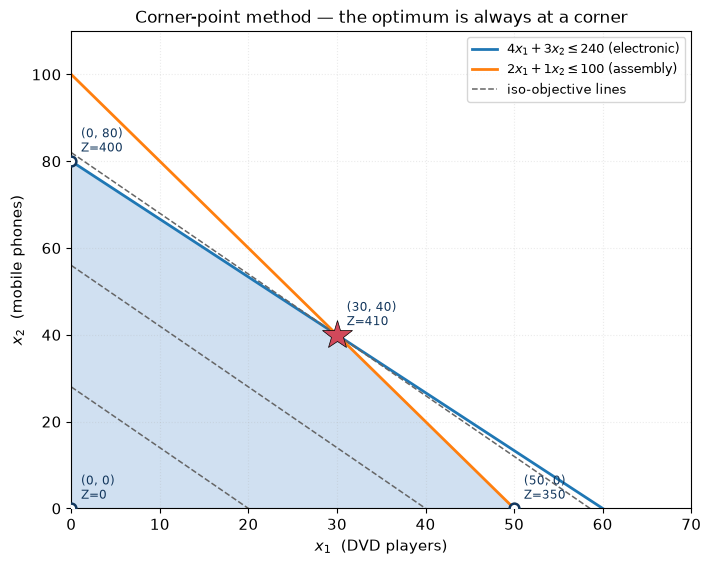

In [11]:
# the same picture, with every corner evaluated
lp_draw(ELEC, obj=(7, 5), xlim=(0, 70), ylim=(0, 110),
        corners=corner_points_from(ELEC), highlight=(30, 40),
        iso=[140, 280, 410],
        labels=("$x_1$  (DVD players)", "$x_2$  (mobile phones)"),
        title="Corner-point method — the optimum is always at a corner")
plt.show()

### 3.5 Graphical solution of a minimisation problem

Back to the photo chemicals:

$$\text{Minimise } Z = 2500x_1 + 3000x_2 \quad\text{s.t.}\quad
x_1 \ge 30,\;\; x_2 \ge 20,\;\; x_1 + x_2 \ge 60,\;\; x_1,x_2 \ge 0$$

The feasible region now opens *upwards and to the right* — it is **unbounded**. That is
fine for a minimisation: we slide the iso-**cost** line *towards* the origin instead of away
from it, and the optimum is still at a corner.

The three corners are

| point | $(x_1, x_2)$ | total cost |
|---|---|---|
| a | $(40, 20)$ | $2500(40) + 3000(20) = \$160{,}000$ |
| b | $(30, 30)$ | $2500(30) + 3000(30) = \$165{,}000$ |
| c | $(30, 50)$ | $2500(30) + 3000(50) = \$225{,}000$ |

The lowest total cost is at point **a**: produce 40 tons of black-and-white chemical and
20 tons of colour chemical for **\$160,000**.

> **A subtlety worth noticing.** Only **a** $(40,20)$ and **b** $(30,30)$ are genuine
> *extreme points* of this region. Point **c** $(30,50)$ sits partway up the vertical edge
> $x_1 = 30$, which runs off to infinity — it is on the boundary but it is not a corner.
> The lecture uses it to show that cost keeps rising as you move up that edge, which is why
> the search never goes that way. The automatic corner finder below therefore reports two
> corners, not three.

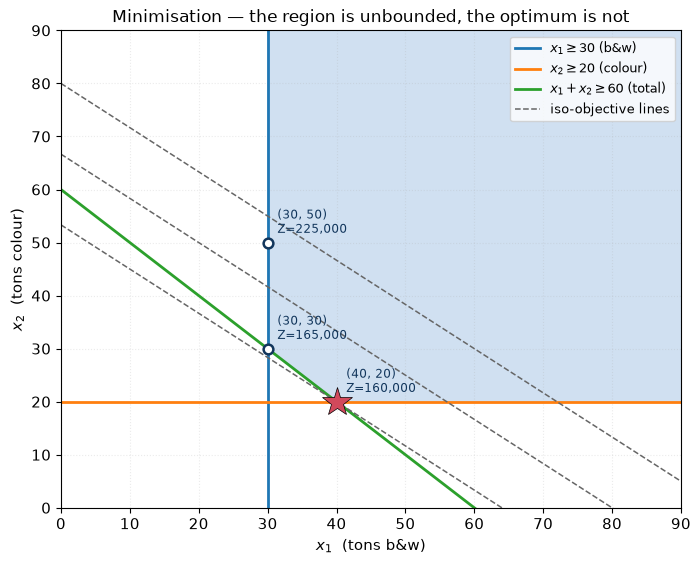

        x1         x2              Z
------------------------------------
        40         20   160,000.0000  <== optimal
        30         30   165,000.0000


In [12]:
CHEM = [(1, 0, ">=", 30, "$x_1 \\geq 30$ (b&w)"),
        (0, 1, ">=", 20, "$x_2 \\geq 20$ (colour)"),
        (1, 1, ">=", 60, "$x_1 + x_2 \\geq 60$ (total)")]

lp_draw(CHEM, obj=(2500, 3000), xlim=(0, 90), ylim=(0, 90),
        corners=[(40, 20), (30, 30), (30, 50)], highlight=(40, 20),
        iso=[160000, 200000, 240000],
        labels=("$x_1$  (tons b&w)", "$x_2$  (tons colour)"),
        title="Minimisation — the region is unbounded, the optimum is not")
plt.show()

corner_table(CHEM, (2500, 3000), sense="min");

In [13]:
# --- interactive: slide the iso-COST line inwards --------------------------
def iso_cost(Z=200000):
    ax = lp_draw(CHEM, obj=(2500, 3000), xlim=(0, 90), ylim=(0, 90),
                 labels=("$x_1$  (tons b&w)", "$x_2$  (tons colour)"),
                 title=f"Iso-cost line  $2500x_1 + 3000x_2 = {Z:,.0f}$")
    xs = np.linspace(0, 90, 200)
    ax.plot(xs, (Z - 2500*xs)/3000, lw=3, color="#d1495b", label=f"cost = ${Z:,.0f}")
    ax.plot(40, 20, "*", ms=18, color="#2a9d8f", mec="k", mew=.5, zorder=6)
    ax.legend(loc="upper right"); plt.show()
    if Z < 160000:
        print(f"${Z:,.0f} is below the minimum — the line misses the feasible region.")
    elif abs(Z - 160000) < 1:
        print("This is the cheapest line that still touches the region: Z* = $160,000 "
              "at (40, 20).")
    else:
        print(f"${Z:,.0f} is feasible but not cheapest — keep sliding towards the origin.")

interact(iso_cost, Z=(100000, 300000, 5000));

interactive(children=(IntSlider(value=200000, description='Z', max=300000, min=100000, step=5000), Output()), …

### 3.6 Solved problem — the airline

$$\text{Maximise } Z = 2500x_1 + 2000x_2 \quad\text{s.t.}\quad
x_1 + x_2 \le 12,\;\; 15x_1 + 10x_2 \le 150,\;\; x_1 \le 9,\;\; x_1,x_2 \ge 0$$

A careful drawing of iso-profit lines parallel to one another indicates that point **D** is
optimal. The maximum profit results from making **six flights to Rome and six to Dublin**:

$$\$2{,}500(6) + \$2{,}000(6) = \$27{,}000$$

Check that the binding constraints are the gate ($6+6=12$) and the crew labour
($15(6)+10(6)=150$) — both are used to the last hour, while the market limit
($x_1 = 6 \le 9$) has 3 flights of slack.

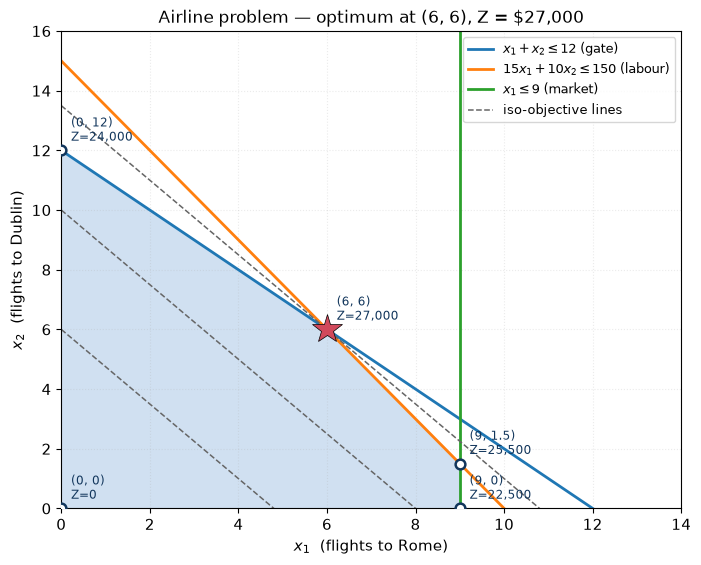

        x1         x2              Z
------------------------------------
         6          6    27,000.0000  <== optimal
         9        1.5    25,500.0000
         0         12    24,000.0000
         9          0    22,500.0000
         0          0         0.0000

Slack at the optimum:
  $x_1 + x_2 \leq 12$ (gate)               used   12.0 /    12   slack    0.0
  $15x_1 + 10x_2 \leq 150$ (labour)        used  150.0 /   150   slack    0.0
  $x_1 \leq 9$ (market)                    used    6.0 /     9   slack    3.0


In [14]:
AIR = [(1, 1, "<=", 12,  "$x_1 + x_2 \\leq 12$ (gate)"),
       (15, 10, "<=", 150, "$15x_1 + 10x_2 \\leq 150$ (labour)"),
       (1, 0, "<=", 9,   "$x_1 \\leq 9$ (market)")]

lp_draw(AIR, obj=(2500, 2000), xlim=(0, 14), ylim=(0, 16),
        corners=corner_points_from(AIR), highlight=(6, 6),
        iso=[12000, 20000, 27000],
        labels=("$x_1$  (flights to Rome)", "$x_2$  (flights to Dublin)"),
        title="Airline problem — optimum at (6, 6), Z = \\$27,000")
plt.show()

corner_table(AIR, (2500, 2000), "max")
print("\nSlack at the optimum:")
for a, b, op, c, lab in AIR:
    print(f"  {lab:<40} used {a*6+b*6:6.1f} / {c:5.0f}   slack {c-(a*6+b*6):6.1f}")

In [15]:
# --- interactive: change the profit coefficients and watch the optimum jump --
def airline_sensitivity(profit_rome=2500, profit_dublin=2000):
    obj = (profit_rome, profit_dublin)
    pts = corner_points_from(AIR)
    zs = [obj[0]*p[0] + obj[1]*p[1] for p in pts]
    i = int(np.argmax(zs))
    lp_draw(AIR, obj=obj, xlim=(0, 14), ylim=(0, 16), corners=pts,
            highlight=pts[i], iso=[zs[i]*f for f in (0.4, 0.7, 1.0)],
            labels=("$x_1$  (Rome)", "$x_2$  (Dublin)"),
            title=f"Z = {profit_rome:g}$x_1$ + {profit_dublin:g}$x_2$  ->  "
                  f"optimum ({pts[i][0]:g}, {pts[i][1]:g}), Z = {zs[i]:,.0f}")
    plt.show()
    ties = [p for p, z in zip(pts, zs) if abs(z - zs[i]) < 1e-6]
    if len(ties) > 1:
        print("Multiple optima: the objective is parallel to a binding constraint —",
              " and ".join(f"({p[0]:g}, {p[1]:g})" for p in ties),
              "and every point between them are all optimal.")

interact(airline_sensitivity,
         profit_rome=(500, 5000, 100),
         profit_dublin=(500, 5000, 100));

interactive(children=(IntSlider(value=2500, description='profit_rome', max=5000, min=500, step=100), IntSlider…

---
## Part 4 — Irregular Types of Linear Programming Problems

For some LP models the general rules do not apply. The special types are:

* **Multiple optimal solutions**
* **Infeasible solutions**
* **Unbounded solutions**

Recognising these on the graph is quick; recognising them in the algebra is the skill that
carries over to problems with more than two variables.

### 4.1 Multiple optimal solutions

This happens when the **objective function is parallel to a constraint line** that forms an
edge of the feasible region.

$$\text{Maximise } Z = 40x_1 + 30x_2 \quad\text{s.t.}\quad
x_1 + 2x_2 \le 40,\;\; 4x_1 + 3x_2 \le 120,\;\; x_1,x_2 \ge 0$$

The objective has slope $-40/30 = -4/3$, and the clay constraint $4x_1+3x_2 \le 120$ has
exactly the same slope. So the iso-profit line arrives at the boundary flush against that
edge: **both endpoints, and every point between them, are optimal.**

$Z = 1200$ at $(30, 0)$ and at $(24, 8)$ — and at $(27, 4)$, and everywhere else on the
segment. For a manager this is good news: several different production plans are equally
profitable, so a secondary criterion (machine wear, customer relations, flexibility) can
decide between them.

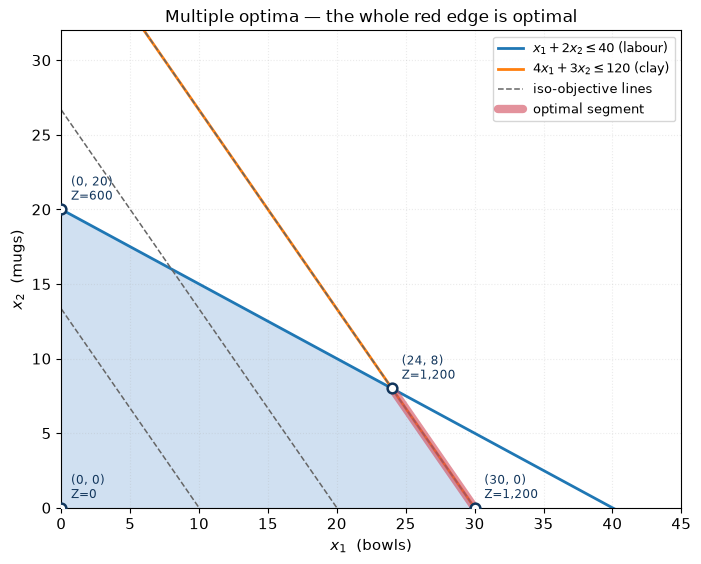

        x1         x2              Z
------------------------------------
        24          8     1,200.0000  <== optimal
        30          0     1,200.0000
         0         20       600.0000
         0          0         0.0000

Every convex combination of (30, 0) and (24, 8) is optimal, e.g.
   t=0.25:  (28.50,  2.00)   Z = 1,200.0
   t=0.5:  (27.00,  4.00)   Z = 1,200.0
   t=0.75:  (25.50,  6.00)   Z = 1,200.0


In [16]:
MULTI = [(1, 2, "<=", 40,  "$x_1 + 2x_2 \\leq 40$ (labour)"),
         (4, 3, "<=", 120, "$4x_1 + 3x_2 \\leq 120$ (clay)")]

ax = lp_draw(MULTI, obj=(40, 30), xlim=(0, 45), ylim=(0, 32),
             corners=corner_points_from(MULTI), iso=[400, 800, 1200],
             labels=("$x_1$  (bowls)", "$x_2$  (mugs)"),
             title="Multiple optima — the whole red edge is optimal")
ax.plot([30, 24], [0, 8], lw=6, color="#d1495b", alpha=.6,
        solid_capstyle="round", zorder=4, label="optimal segment")
ax.legend(loc="upper right"); plt.show()

corner_table(MULTI, (40, 30), "max")
print("\nEvery convex combination of (30, 0) and (24, 8) is optimal, e.g.")
for t in (0.25, 0.5, 0.75):
    p = (1-t)*np.array([30, 0]) + t*np.array([24, 8])
    print(f"   t={t}:  ({p[0]:5.2f}, {p[1]:5.2f})   Z = {40*p[0]+30*p[1]:,.1f}")

### 4.2 An infeasible problem

**Every possible solution violates at least one constraint** — the constraints contradict
one another and the feasible region is empty.

$$\text{Maximise } Z = 5x_1 + 3x_2 \quad\text{s.t.}\quad
4x_1 + 2x_2 \le 8,\;\; x_1 \ge 4,\;\; x_2 \ge 6,\;\; x_1,x_2 \ge 0$$

The arithmetic is immediate: $x_1 \ge 4$ and $x_2 \ge 6$ force
$4x_1 + 2x_2 \ge 16 + 12 = 28$, which can never be $\le 8$.

Infeasibility is almost always a **modelling** message, not a mathematical one: a promise
has been made that the resources cannot keep. The fix is to relax a constraint (buy more
capacity, renegotiate the minimum order), not to look for a cleverer solution method.

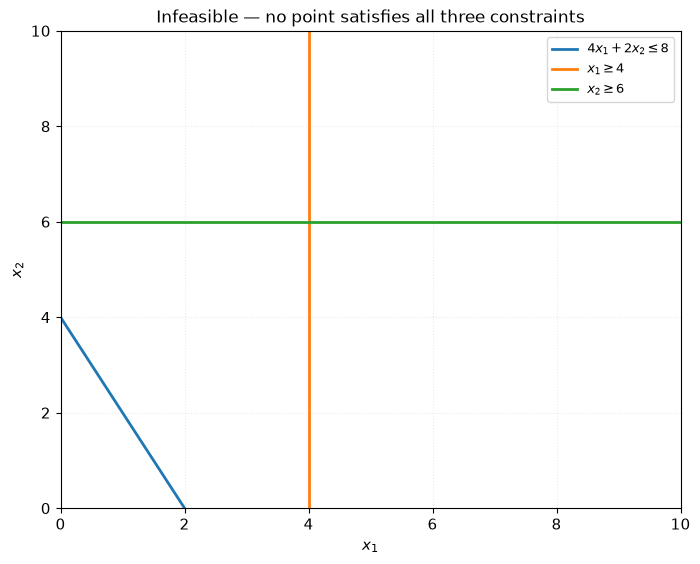

corner points found: []  -> the region is empty
x1 >= 4 and x2 >= 6  =>  4x1 + 2x2 >= 28 > 8.  Contradiction.


In [17]:
INFEAS = [(4, 2, "<=", 8, "$4x_1 + 2x_2 \\leq 8$"),
          (1, 0, ">=", 4, "$x_1 \\geq 4$"),
          (0, 1, ">=", 6, "$x_2 \\geq 6$")]

lp_draw(INFEAS, obj=(5, 3), xlim=(0, 10), ylim=(0, 10),
        title="Infeasible — no point satisfies all three constraints")
plt.show()
print("corner points found:", corner_points_from(INFEAS), " -> the region is empty")
print("x1 >= 4 and x2 >= 6  =>  4x1 + 2x2 >= 28 > 8.  Contradiction.")

### 4.3 An unbounded problem

The **value of the objective function increases indefinitely**: the feasible region extends
without limit in a direction along which the objective keeps improving.

$$\text{Maximise } Z = 4x_1 + 2x_2 \quad\text{s.t.}\quad
x_1 \ge 4,\;\; x_2 \le 2,\;\; x_1,x_2 \ge 0$$

Nothing stops $x_1$ from growing, and every extra unit of $x_1$ adds 4 to $Z$, so $Z$ has no
maximum.

Like infeasibility, unboundedness is a **modelling error** in practice: some real limit
(demand, capacity, budget, raw material) has been left out of the model. No real business
earns infinite profit.

Note that an unbounded *region* is not the same thing as an unbounded *problem* — the
photo-chemicals minimisation in §3.5 had an unbounded region but a perfectly finite optimum.
It is the combination of the region *and the direction the objective pushes* that matters.

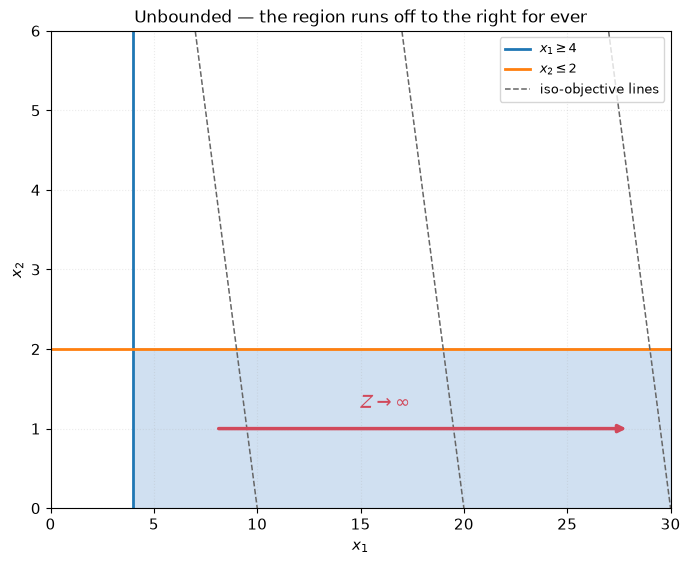

  x1 =     4, x2 = 2  ->  Z =       20
  x1 =    40, x2 = 2  ->  Z =      164
  x1 =   400, x2 = 2  ->  Z =    1,604
  x1 =  4000, x2 = 2  ->  Z =   16,004
  ... no maximum exists.


In [18]:
UNB = [(1, 0, ">=", 4, "$x_1 \\geq 4$"),
       (0, 1, "<=", 2, "$x_2 \\leq 2$")]

ax = lp_draw(UNB, obj=(4, 2), xlim=(0, 30), ylim=(0, 6), iso=[40, 80, 120],
             title="Unbounded — the region runs off to the right for ever")
ax.annotate("", xy=(28, 1), xytext=(8, 1),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#d1495b"))
ax.text(15, 1.25, "$Z \\to \\infty$", color="#d1495b", fontsize=13)
plt.show()

for x1 in (4, 40, 400, 4000):
    print(f"  x1 = {x1:>5}, x2 = 2  ->  Z = {4*x1 + 2*2:>8,}")
print("  ... no maximum exists.")

### 4.4 Practice — classify these four

From the lecture. For each one, sketch it (or run the cell), then say whether it has a unique
optimum, multiple optima, no feasible solution, or an unbounded objective.

**(a)** Maximise $Z = 6x_1 - 2x_2$ s.t. $x_1 - x_2 \le 1$, $3x_1 - x_2 \le 6$, $x_1, x_2 \ge 0$

**(b)** Maximise $Z = 5x_1 + 6x_2$ s.t. $x_1 - 2x_2 \ge 1$, $-2x_1 + 3x_2 \ge 2$,
$x_1, x_2$ **unrestricted in sign**

**(c)** Maximise $Z = 3x_1 + 2x_2$ s.t. $2x_1 + x_2 \le 2$, $3x_1 + x_2 \ge 12$, $x_1, x_2 \ge 0$

**(d)** Maximise $Z = 5x_1 + 6x_2$ s.t. $x_1 + x_2 \le 10$, $x_1 = 5$, $x_1, x_2 \ge 0$

<details>
<summary><b>Answers</b></summary>

**(a) Unbounded.** Along the ray $x_1 = 1+t,\, x_2 = t$ both constraints stay satisfied
(the first is tight, the second becomes $3+2t \le 6$ — so actually the binding limit is
$3x_1 - x_2 \le 6$; follow the edge $x_1 - x_2 = 1$ and $Z = 6x_1 - 2x_2 = 4x_1 + \ldots$
keeps growing). $Z \to \infty$.

**(b) A finite optimum at a negative point** — which is only possible because the variables
are unrestricted in sign. Adding twice the first constraint to the second gives
$-x_2 \ge 4$, i.e. $x_2 \le -4$; the optimum is $(-7, -4)$ with $Z = -59$. A good reminder
that "unrestricted in sign" changes the picture completely — the feasible region is no
longer confined to the first quadrant.

**(c) Infeasible.** $2x_1 + x_2 \le 2$ and $3x_1 + x_2 \ge 12$ cannot both hold for
$x_1,x_2 \ge 0$.

**(d) Unique optimum.** The equality pins $x_1 = 5$; the feasible set is the segment from
$(5,0)$ to $(5,5)$, and $Z = 5(5) + 6x_2$ is maximised at $(5, 5)$ with $Z = 55$.

</details>

Run the next cell after you have made your own guesses — the toolkit in Part 5 will
classify all four automatically.

---
## Part 5 — A reusable LP toolkit

Everything so far was hand-coded for one example at a time. Now we build a small library
that works for **any** two-variable LP, and save it as `lp_tools.py` next to this notebook so
you can `import` it from your own scripts.

The library has four layers, one per cell below:

1. **Model containers** — a tidy `LPModel` object.
2. **An LP-file parser** — read the standard CPLEX `.lp` text format.
3. **A corner-point solver** — including infeasible / unbounded / multiple-optima detection.
4. **A plotter** — feasible region, constraint lines, corner points, iso-objective lines.

Each cell uses the `%%writefile` magic, so running them *both* creates the file on disk *and*
lets you read the code. Run them in order.

#### 5.1 Model containers

In [19]:
%%writefile lp_tools.py
"""
lp_tools.py -- a small, teaching-oriented toolkit for two-variable Linear Programs.
Parses LP files (CPLEX LP-format subset), solves them by the corner-point method,
and draws the graphical solution.
"""
from __future__ import annotations

import re
import itertools
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

TOL = 1e-7

# ----------------------------------------------------------------------------
# 1. Model containers
# ----------------------------------------------------------------------------

@dataclass
class Constraint:
    name: str
    coeffs: dict          # {var: coefficient}
    op: str               # '<=', '>=', '='
    rhs: float

    def as_text(self, order):
        return f"{_expr_text(self.coeffs, order)} {self.op} {_num(self.rhs)}"


@dataclass
class LPModel:
    sense: str = "max"                  # 'max' or 'min'
    obj_name: str = "obj"
    obj: dict = field(default_factory=dict)
    obj_const: float = 0.0
    constraints: list = field(default_factory=list)
    lower: dict = field(default_factory=dict)   # var -> lower bound (-inf allowed)
    upper: dict = field(default_factory=dict)   # var -> upper bound (+inf allowed)
    var_order: list = field(default_factory=list)

    # -- convenience ---------------------------------------------------------
    @property
    def n_vars(self):
        return len(self.var_order)

    def __str__(self):
        o = self.var_order
        head = "Maximize" if self.sense == "max" else "Minimize"
        lines = [f"{head}  Z = {_expr_text(self.obj, o)}"
                 + (f" + {_num(self.obj_const)}" if self.obj_const else ""),
                 "subject to:"]
        for c in self.constraints:
            lines.append(f"    {c.name+':':<14}{c.as_text(o)}")
        for v in o:
            lo, up = self.lower.get(v, 0.0), self.upper.get(v, np.inf)
            bits = []
            if lo == -np.inf and up == np.inf:
                bits.append(f"{v} free")
            else:
                if lo != -np.inf:
                    bits.append(f"{v} >= {_num(lo)}")
                if up != np.inf:
                    bits.append(f"{v} <= {_num(up)}")
            lines.append("    " + ", ".join(bits))
        return "\n".join(lines)


def _num(x):
    if x == int(x):
        return str(int(x))
    return f"{x:g}"


def _expr_text(coeffs, order):
    parts = []
    for v in order:
        c = coeffs.get(v, 0.0)
        if c == 0:
            continue
        sign = "-" if c < 0 else ("+" if parts else "")
        a = abs(c)
        mag = "" if a == 1 else _num(a)
        parts.append(f"{sign} {mag}{v}".strip() if parts else f"{sign}{mag}{v}")
    return " ".join(parts) if parts else "0"

Overwriting lp_tools.py


#### 5.2 The LP-file parser

We use the **CPLEX LP format**, the de-facto plain-text standard that almost every solver
(CPLEX, Gurobi, GLPK, HiGHS, CBC, PuLP) can read and write. A file looks like this:

```
\ comments start with a backslash
Maximize
 profit: 7 x1 + 5 x2
Subject To
 electronics: 4 x1 + 3 x2 <= 240
 assembly:    2 x1 + 1 x2 <= 100
Bounds
 x1 >= 0
 x2 >= 0
End
```

The rules the parser below implements:

| Section | Accepted keywords | Notes |
|---|---|---|
| objective | `Maximize` / `Maximise` / `Max` / `Minimize` / `Min` | optional `name:` prefix |
| constraints | `Subject To` / `such that` / `st` / `s.t.` | one constraint per line, optional `name:` prefix, operators `<=` `>=` `=` (also `=<`, `=>`, `<`, `>`) |
| bounds | `Bounds` | `x1 >= 0`, `x1 <= 10`, `0 <= x1 <= 10`, `x1 = 5`, `x1 free`, `-inf` / `+inf` |
| free variables | `Free` | list variable names |
| end | `End` | optional |

Default bound for every variable is $x \ge 0$, exactly as in the lecture's non-negativity
constraint. Variables may appear on both sides of a constraint
(`3 x1 + 2 >= x2 + 5` is parsed correctly) and coefficients may be written
`4x1`, `4 x1` or `4*x1`.

In [20]:
%%writefile -a lp_tools.py
# ----------------------------------------------------------------------------
# 2. LP-file parser  (CPLEX LP format, the subset we need)
# ----------------------------------------------------------------------------

_SECTION = {
    "maximize": "max", "maximise": "max", "max": "max",
    "minimize": "min", "minimise": "min", "min": "min",
    "subject to": "st", "such that": "st", "st": "st", "s.t.": "st",
    "bounds": "bounds", "bound": "bounds",
    "free": "free",
    "end": "end",
}

_TERM = re.compile(r"""([+-]?)\s*           # sign
                       (\d*\.?\d*(?:[eE][+-]?\d+)?)\s*  # optional number
                       \*?\s*
                       ([A-Za-z_][A-Za-z0-9_.\[\]]*)     # variable name
                    """, re.X)
_OPS = re.compile(r"(<=|>=|=<|=>|<|>|=)")


def _parse_expr(s, model):
    """Turn '3 x1 - 2.5x2 + 7' into ({'x1':3,'x2':-2.5}, 7.0)."""
    coeffs, const = {}, 0.0
    s = s.strip()
    pos = 0
    token = re.compile(r"\s*([+-]?)\s*([0-9]*\.?[0-9]+(?:[eE][+-]?[0-9]+)?)?\s*"
                       r"\*?\s*([A-Za-z_][A-Za-z0-9_.\[\]]*)?")
    while pos < len(s):
        m = token.match(s, pos)
        if not m or m.end() == pos:
            break
        sign, num, var = m.group(1), m.group(2), m.group(3)
        if num is None and var is None:
            break
        mult = -1.0 if sign == "-" else 1.0
        val = float(num) if num is not None else 1.0
        if var:
            if var not in model.var_order:
                model.var_order.append(var)
            coeffs[var] = coeffs.get(var, 0.0) + mult * val
        else:
            const += mult * val
        pos = m.end()
    return coeffs, const


def parse_lp(text: str) -> LPModel:
    """Parse an LP file (string) in CPLEX LP format into an LPModel."""
    model = LPModel()
    # strip comments ( \ ... to end of line ) and blank lines
    raw = []
    for line in text.splitlines():
        line = line.split("\\")[0]
        if line.strip():
            raw.append(line.rstrip())

    section, buf, unnamed = None, [], itertools.count(1)

    def flush():
        """Process the statement accumulated in `buf`."""
        stmt = " ".join(buf).strip()
        buf.clear()
        if not stmt:
            return
        if section == "obj":
            name = model.obj_name
            if ":" in stmt.split("<")[0] and re.match(r"^\s*[A-Za-z_][\w.]*\s*:", stmt):
                name, stmt = stmt.split(":", 1)
                name = name.strip()
            model.obj_name = name
            c, k = _parse_expr(stmt, model)
            model.obj, model.obj_const = c, k
        elif section == "st":
            name = None
            if re.match(r"^\s*[A-Za-z_][\w.]*\s*:", stmt):
                name, stmt = stmt.split(":", 1)
                name = name.strip()
            m = _OPS.search(stmt)
            if not m:
                raise ValueError(f"Constraint without a relational operator: {stmt!r}")
            lhs, op, rhs = stmt[:m.start()], m.group(1), stmt[m.end():]
            op = {"=<": "<=", "=>": ">=", "<": "<=", ">": ">="}.get(op, op)
            lc, lk = _parse_expr(lhs, model)
            rc, rk = _parse_expr(rhs, model)
            coeffs = {v: lc.get(v, 0.0) - rc.get(v, 0.0)
                      for v in set(lc) | set(rc)}
            coeffs = {v: c for v, c in coeffs.items() if abs(c) > TOL}
            model.constraints.append(
                Constraint(name or f"c{next(unnamed)}", coeffs, op, rk - lk))
        elif section == "bounds":
            _parse_bound(stmt, model)
        elif section == "free":
            for v in re.findall(r"[A-Za-z_][A-Za-z0-9_.\[\]]*", stmt):
                if v not in model.var_order:
                    model.var_order.append(v)
                model.lower[v], model.upper[v] = -np.inf, np.inf

    for line in raw:
        key = line.strip().lower().rstrip(":")
        if key in _SECTION:
            flush()
            tag = _SECTION[key]
            if tag in ("max", "min"):
                model.sense, section = tag, "obj"
            elif tag == "end":
                flush()
                section = None
                break
            else:
                section = tag
            continue
        if section is None:
            continue
        # a new statement starts when the previous one is complete
        if section in ("st", "bounds", "free") and buf:
            flush()
        buf.append(line)
    flush()

    # default bounds: x >= 0
    for v in model.var_order:
        model.lower.setdefault(v, 0.0)
        model.upper.setdefault(v, np.inf)
    return model


def _parse_bound(stmt, model):
    s = stmt.strip()
    if re.match(r"^[A-Za-z_][\w.\[\]]*\s+free$", s, re.I):
        v = s.split()[0]
        if v not in model.var_order:
            model.var_order.append(v)
        model.lower[v], model.upper[v] = -np.inf, np.inf
        return
    parts = _OPS.split(s)
    parts = [p.strip() for p in parts]
    def norm(o):
        return {"=<": "<=", "=>": ">=", "<": "<=", ">": ">="}.get(o, o)

    if len(parts) == 5:                      # lo <= x <= up
        lo, o1, v, o2, up = parts
        if v not in model.var_order:
            model.var_order.append(v)
        model.lower[v] = _val(lo)
        model.upper[v] = _val(up)
    elif len(parts) == 3:
        a, op, b = parts[0], norm(parts[1]), parts[2]
        if re.match(r"^[A-Za-z_]", a):
            v, val = a, _val(b)
        else:
            v, val = b, _val(a)
            op = {"<=": ">=", ">=": "<=", "=": "="}[op]
        if v not in model.var_order:
            model.var_order.append(v)
        if op == "<=":
            model.upper[v] = val
        elif op == ">=":
            model.lower[v] = val
        else:
            model.lower[v] = model.upper[v] = val


def _val(tok):
    tok = tok.strip().lower().replace(" ", "")
    if tok in ("inf", "+inf", "infinity", "+infinity"):
        return np.inf
    if tok in ("-inf", "-infinity"):
        return -np.inf
    return float(tok)


def load_lp(path) -> LPModel:
    with open(path) as f:
        return parse_lp(f.read())

Appending to lp_tools.py


#### 5.3 The corner-point solver

Every constraint — including the bounds — becomes a **half-plane** $ax_1 + bx_2 \;\{\le,=,\ge\}\; c$.
The solver then:

1. intersects **every pair** of constraint lines (there are $\binom{m}{2}$ of them);
2. keeps an intersection only if it satisfies *all* the other constraints → that is a corner
   point of the feasible region;
3. evaluates $Z$ at each corner and takes the best.

Two extra checks make it honest about the irregular cases of Part 4:

* **Infeasible** — no corner survives step 2 *and* a feasibility LP confirms the region is
  empty.
* **Unbounded** — there is a direction $d$ in the *recession cone* (i.e. $Ad \le 0$ for the
  $\le$ rows, etc.) along which $c^{\!\top}d$ improves. Then $Z$ grows without limit.
* **Multiple optima** — more than one corner attains the best value.

In [21]:
%%writefile -a lp_tools.py
# ----------------------------------------------------------------------------
# 3. Half-plane representation + corner-point solver
# ----------------------------------------------------------------------------

@dataclass
class HalfPlane:
    a: float
    b: float
    op: str      # '<=', '>=', '='
    c: float
    label: str

    def slack(self, x, y):
        return self.c - (self.a * x + self.b * y)

    def holds(self, x, y, tol=1e-6):
        lhs = self.a * x + self.b * y
        if self.op == "<=":
            return lhs <= self.c + tol
        if self.op == ">=":
            return lhs >= self.c - tol
        return abs(lhs - self.c) <= tol


def to_halfplanes(model: LPModel):
    """All constraints + bounds of a 2-variable model as half-planes."""
    if model.n_vars != 2:
        raise ValueError(
            f"The graphical method needs exactly 2 decision variables, "
            f"this model has {model.n_vars}: {model.var_order}")
    v1, v2 = model.var_order
    hps = [HalfPlane(c.coeffs.get(v1, 0.0), c.coeffs.get(v2, 0.0),
                     c.op, c.rhs, c.name) for c in model.constraints]
    for i, v in enumerate((v1, v2)):
        a, b = (1.0, 0.0) if i == 0 else (0.0, 1.0)
        lo, up = model.lower[v], model.upper[v]
        if lo != -np.inf:
            hps.append(HalfPlane(a, b, ">=", lo, f"{v} >= {_num(lo)}"))
        if up != np.inf:
            hps.append(HalfPlane(a, b, "<=", up, f"{v} <= {_num(up)}"))
    return hps


def _intersect(h1, h2):
    A = np.array([[h1.a, h1.b], [h2.a, h2.b]], float)
    if abs(np.linalg.det(A)) < 1e-12:
        return None
    return np.linalg.solve(A, np.array([h1.c, h2.c], float))


def corner_points(model: LPModel, tol=1e-6):
    """Every vertex of the feasible region, with the constraints binding there."""
    hps = to_halfplanes(model)
    pts = []
    for h1, h2 in itertools.combinations(hps, 2):
        p = _intersect(h1, h2)
        if p is None:
            continue
        if all(h.holds(p[0], p[1], tol) for h in hps):
            for q, _ in pts:
                if abs(q[0] - p[0]) < 1e-6 and abs(q[1] - p[1]) < 1e-6:
                    break
            else:
                binding = [h.label for h in hps
                           if abs(h.a * p[0] + h.b * p[1] - h.c) < 1e-6]
                pts.append((p, binding))
    return pts


def objective_value(model, x, y):
    v1, v2 = model.var_order
    return (model.obj.get(v1, 0.0) * x + model.obj.get(v2, 0.0) * y
            + model.obj_const)


@dataclass
class LPResult:
    status: str                       # 'optimal', 'infeasible', 'unbounded'
    model: LPModel = None
    x: tuple = None
    z: float = None
    corners: list = field(default_factory=list)     # [(point, binding, z)]
    optimal_corners: list = field(default_factory=list)
    multiple: bool = False
    message: str = ""

    def __str__(self):
        if self.status != "optimal":
            return f"Status: {self.status.upper()} -- {self.message}"
        v1, v2 = self.model.var_order
        s = [f"Status : OPTIMAL",
             f"{v1:<6}= {self.x[0]:.6g}",
             f"{v2:<6}= {self.x[1]:.6g}",
             f"Z      = {self.z:.6g}"]
        if self.multiple:
            alt = ", ".join(f"({p[0]:.4g}, {p[1]:.4g})"
                            for p, _, _ in self.optimal_corners)
            s.append(f"\nMultiple optimal solutions: every point on the segment "
                     f"between {alt} is optimal.")
        return "\n".join(s)

    def corner_table(self):
        try:
            import pandas as pd
        except ImportError:
            return None
        v1, v2 = self.model.var_order
        rows = [{v1: round(p[0], 6), v2: round(p[1], 6), "Z": round(z, 6),
                 "binding constraints": ", ".join(b), "optimal": "  <== " if
                 any(p is q for q, _, _ in self.optimal_corners) else ""}
                for p, b, z in self.corners]
        return pd.DataFrame(rows).sort_values("Z",
                ascending=(self.model.sense == "min")).reset_index(drop=True)


def solve_lp(model: LPModel, tol=1e-6) -> LPResult:
    """Corner-point (extreme-point) solution of a 2-variable LP."""
    hps = to_halfplanes(model)
    raw = corner_points(model, tol)
    corners = [(p, b, objective_value(model, p[0], p[1])) for p, b in raw]

    feasible = _feasible_somewhere(model, hps, corners)
    if not feasible:
        return LPResult("infeasible", model,
                        message="every point violates at least one constraint, "
                                "the feasible region is empty.")

    unbounded, ray = _unbounded_direction(model, hps)
    if unbounded:
        return LPResult("unbounded", model, corners=corners,
                        message=f"the objective improves without limit along the "
                                f"direction {np.round(ray, 4).tolist()}.")

    if not corners:
        return LPResult("unbounded", model,
                        message="the feasible region has no extreme point "
                                "(unbounded in both directions).")

    best = max(c[2] for c in corners) if model.sense == "max" \
        else min(c[2] for c in corners)
    opt = [c for c in corners if abs(c[2] - best) < 1e-7]
    return LPResult("optimal", model, x=tuple(opt[0][0]), z=best,
                    corners=corners, optimal_corners=opt,
                    multiple=len(opt) > 1)


def _feasible_somewhere(model, hps, corners):
    if corners:
        return True
    # fall back on a linear-programming feasibility check
    from scipy.optimize import linprog
    A_ub, b_ub, A_eq, b_eq = [], [], [], []
    for h in hps:
        if h.op == "<=":
            A_ub.append([h.a, h.b]); b_ub.append(h.c)
        elif h.op == ">=":
            A_ub.append([-h.a, -h.b]); b_ub.append(-h.c)
        else:
            A_eq.append([h.a, h.b]); b_eq.append(h.c)
    r = linprog(c=[0, 0],
                A_ub=A_ub or None, b_ub=b_ub or None,
                A_eq=A_eq or None, b_eq=b_eq or None,
                bounds=[(None, None), (None, None)], method="highs")
    return r.status == 0


def _unbounded_direction(model, hps):
    """Is there a feasible ray along which the objective keeps improving?"""
    from scipy.optimize import linprog
    v1, v2 = model.var_order
    c = np.array([model.obj.get(v1, 0.0), model.obj.get(v2, 0.0)], float)
    if not np.any(c):
        return False, None
    # maximise c.d over the recession cone, |d| bounded by a box
    A_ub, b_ub, A_eq, b_eq = [], [], [], []
    for h in hps:
        if h.op == "<=":
            A_ub.append([h.a, h.b]); b_ub.append(0.0)
        elif h.op == ">=":
            A_ub.append([-h.a, -h.b]); b_ub.append(0.0)
        else:
            A_eq.append([h.a, h.b]); b_eq.append(0.0)
    obj = -c if model.sense == "max" else c
    r = linprog(c=obj, A_ub=A_ub or None, b_ub=b_ub or None,
                A_eq=A_eq or None, b_eq=b_eq or None,
                bounds=[(-1, 1), (-1, 1)], method="highs")
    if r.status == 0:
        gain = c @ r.x
        improves = gain > 1e-7 if model.sense == "max" else gain < -1e-7
        if improves:
            return True, r.x
    return False, None

Appending to lp_tools.py


#### 5.4 The plotter

The feasible region is drawn as a **pixel mask**: a fine grid is tested against every
half-plane and the surviving pixels are shaded. This is less elegant than building a polygon,
but it is bullet-proof — it copes with unbounded regions, empty regions, equality constraints
that collapse the region to a segment, and regions that are a single point.

In [22]:
%%writefile -a lp_tools.py
# ----------------------------------------------------------------------------
# 4. Plotting
# ----------------------------------------------------------------------------

def _plot_window(model, corners, pad=0.25, unbounded=False):
    xs, ys = [0.0], [0.0]
    for p, _, _ in corners:
        xs.append(p[0]); ys.append(p[1])
    for h in to_halfplanes(model):
        if abs(h.b) > TOL:
            ys.append(h.c / h.b)
        if abs(h.a) > TOL:
            xs.append(h.c / h.a)
    xs = [v for v in xs if np.isfinite(v)]
    ys = [v for v in ys if np.isfinite(v)]
    xlo, xhi = min(xs), max(xs)
    ylo, yhi = min(ys), max(ys)
    if unbounded:
        pad = max(pad, 0.9)
    dx = max(xhi - xlo, 1.0) * pad
    dy = max(yhi - ylo, 1.0) * pad
    return (xlo - dx, xhi + dx, ylo - dy, yhi + dy)


def plot_lp(model: LPModel, result: LPResult = None, iso_values=None,
            ax=None, show_corners=True, shade=True, title=None,
            window=None, figsize=(8, 6.5), grid_n=600):
    """Draw constraint lines, the feasible region, corner points and iso-lines."""
    if result is None:
        result = solve_lp(model)
    v1, v2 = model.var_order
    hps = to_halfplanes(model)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    x0, x1, y0, y1 = window or _plot_window(
        model, result.corners, unbounded=(result.status == "unbounded"))
    x0, y0 = min(x0, 0), min(y0, 0)

    # --- feasible region as a pixel mask (works for bounded and unbounded) ---
    if shade:
        gx = np.linspace(x0, x1, grid_n)
        gy = np.linspace(y0, y1, grid_n)
        X, Y = np.meshgrid(gx, gy)
        mask = np.ones_like(X, dtype=bool)
        scale = max(x1 - x0, y1 - y0)
        for h in hps:
            lhs = h.a * X + h.b * Y
            eps = 1e-9 * max(1.0, abs(h.c))
            if h.op == "<=":
                mask &= lhs <= h.c + eps
            elif h.op == ">=":
                mask &= lhs >= h.c - eps
            else:
                mask &= np.abs(lhs - h.c) <= 5e-3 * scale
        if mask.any():
            ax.contourf(X, Y, mask.astype(float), levels=[0.5, 1.5],
                        colors=["#7ba7d7"], alpha=0.35, zorder=0)

        # a feasible set that is only a segment or a point is hard to see
        degenerate = (mask.sum() < 0.01 * mask.size
                      or any(h.op == "=" for h in hps))
        if degenerate and len(result.corners) == 2:
            (p, q) = [c[0] for c in result.corners]
            ax.plot([p[0], q[0]], [p[1], q[1]], color="#1f4e79", lw=6,
                    alpha=0.45, solid_capstyle="round", zorder=1)
        elif len(result.corners) == 1 and not mask.any():
            ax.plot(*result.corners[0][0], "o", ms=14, color="#7ba7d7",
                    alpha=0.6, zorder=1)

    # --- constraint lines ----------------------------------------------------
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for i, c in enumerate(model.constraints):
        a, b = c.coeffs.get(v1, 0.0), c.coeffs.get(v2, 0.0)
        col = colors[i % 10]
        lbl = f"{c.name}: {c.as_text(model.var_order)}"
        ls = "-" if c.op != "=" else "-"
        if abs(b) > TOL:
            xx = np.array([x0, x1])
            ax.plot(xx, (c.rhs - a * xx) / b, color=col, lw=2, ls=ls, label=lbl)
        elif abs(a) > TOL:
            ax.axvline(c.rhs / a, color=col, lw=2, ls=ls, label=lbl)

    # --- axes / non-negativity ----------------------------------------------
    ax.axhline(0, color="0.35", lw=1.2)
    ax.axvline(0, color="0.35", lw=1.2)

    # --- iso-objective lines -------------------------------------------------
    c1, c2 = model.obj.get(v1, 0.0), model.obj.get(v2, 0.0)
    if iso_values is None and (abs(c1) > TOL or abs(c2) > TOL):
        # space the iso-lines so that they are visibly apart on this window
        step = 0.26 * np.hypot(c1, c2) * max(x1 - x0, y1 - y0)
        base = result.z if result.status == "optimal" else \
            objective_value(model, (x0 + x1) / 2, (y0 + y1) / 2)
        sgn = -1.0 if model.sense == "max" else 1.0
        iso_values = [base + sgn * k * step for k in range(4)]
    if iso_values and (abs(c1) > TOL or abs(c2) > TOL):
        for k, z in enumerate(iso_values):
            zz = z - model.obj_const
            lab = "iso-objective lines" if k == 0 else None
            if abs(c2) > TOL:
                xx = np.array([x0, x1])
                ax.plot(xx, (zz - c1 * xx) / c2, color="0.45", lw=1,
                        ls="--", alpha=0.8, label=lab)
            elif abs(c1) > TOL:
                ax.axvline(zz / c1, color="0.45", lw=1, ls="--",
                           alpha=0.8, label=lab)

    # --- corner points -------------------------------------------------------
    if show_corners:
        for p, _, z in result.corners:
            ax.plot(*p, "o", ms=7, mfc="white", mec="#12365c", mew=1.8, zorder=5)
            ax.annotate(f"({p[0]:.4g}, {p[1]:.4g})\nZ={z:.5g}", p,
                        textcoords="offset points", xytext=(7, 7),
                        fontsize=8, color="#12365c")
    if result.status == "optimal":
        for p, _, _ in result.optimal_corners:
            ax.plot(*p, "*", ms=20, color="#d1495b", zorder=6)

    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_xlabel(v1); ax.set_ylabel(v2)
    head = "Maximize" if model.sense == "max" else "Minimize"
    ax.set_title(title or f"{head} Z = {_expr_text(model.obj, model.var_order)}"
                          f"   -- {result.status.upper()}")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
    ax.grid(alpha=0.25, ls=":")
    return ax


def solve_and_plot(source, **kw):
    """`source` may be a path to an .lp file, LP text, or an LPModel."""
    if isinstance(source, LPModel):
        model = source
    elif isinstance(source, str) and ("\n" in source or not source.endswith(".lp")):
        model = parse_lp(source)
    else:
        model = load_lp(source)
    res = solve_lp(model)
    print(model, end="\n\n")
    print(res)
    tbl = res.corner_table()
    if tbl is not None and len(tbl):
        print("\nCorner points:")
        print(tbl.to_string(index=False))
    plot_lp(model, res, **kw)
    plt.show()
    return model, res

Appending to lp_tools.py


In [23]:
import importlib, lp_tools
importlib.reload(lp_tools)
from lp_tools import (LPModel, Constraint, parse_lp, load_lp, solve_lp,
                      plot_lp, solve_and_plot, corner_points, to_halfplanes)
print("lp_tools loaded ->", lp_tools.__file__)

lp_tools loaded -> c:\Users\islam\Documents\GitHub\IME312_OpearationsResearch1\Fall2026\Lecture2\lp_tools.py


### 5.5 The four practice problems of §4.4, solved automatically


(a) unbounded?
----------------------------------------------------------------
Maximize  Z = 6x1 - 2x2
subject to:
    c1:           x1 - x2 <= 1
    c2:           3x1 - x2 <= 6
    x1 >= 0
    x2 >= 0

Status : OPTIMAL
x1    = 2.5
x2    = 1.5
Z      = 12


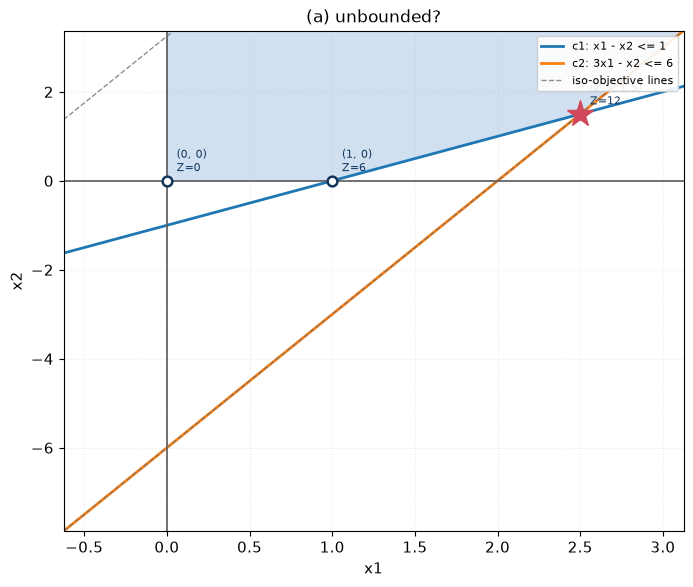


(b) free variables
----------------------------------------------------------------
Maximize  Z = 5x1 + 6x2
subject to:
    c1:           x1 - 2x2 >= 1
    c2:           -2x1 + 3x2 >= 2
    x1 free
    x2 free

Status : OPTIMAL
x1    = -7
x2    = -4
Z      = -59


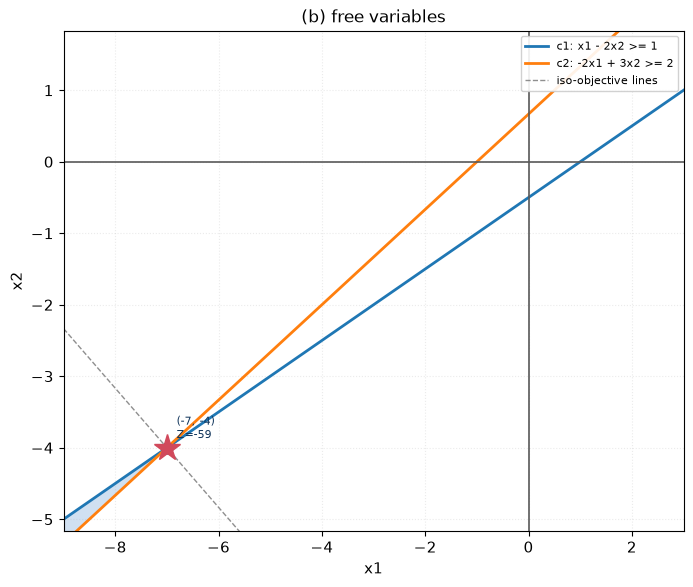


(c) infeasible?
----------------------------------------------------------------
Maximize  Z = 3x1 + 2x2
subject to:
    c1:           2x1 + x2 <= 2
    c2:           3x1 + x2 >= 12
    x1 >= 0
    x2 >= 0

Status: INFEASIBLE -- every point violates at least one constraint, the feasible region is empty.


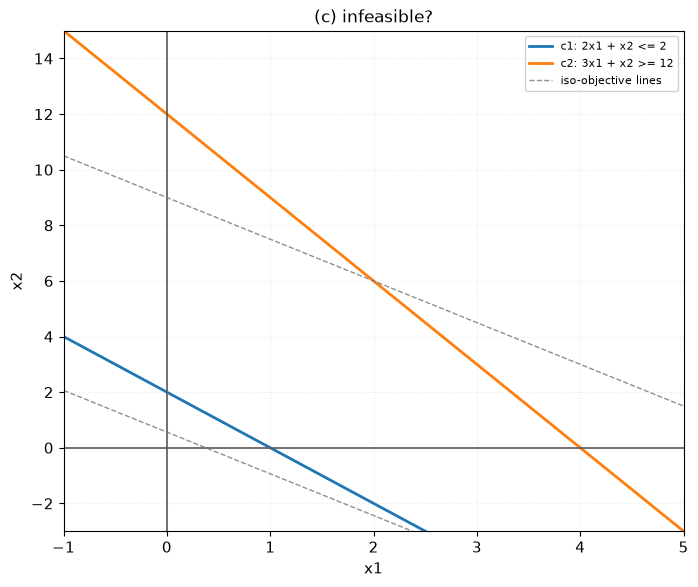


(d) equality
----------------------------------------------------------------
Maximize  Z = 5x1 + 6x2
subject to:
    c1:           x1 + x2 <= 10
    c2:           x1 = 5
    x1 >= 0
    x2 >= 0

Status : OPTIMAL
x1    = 5
x2    = 5
Z      = 55


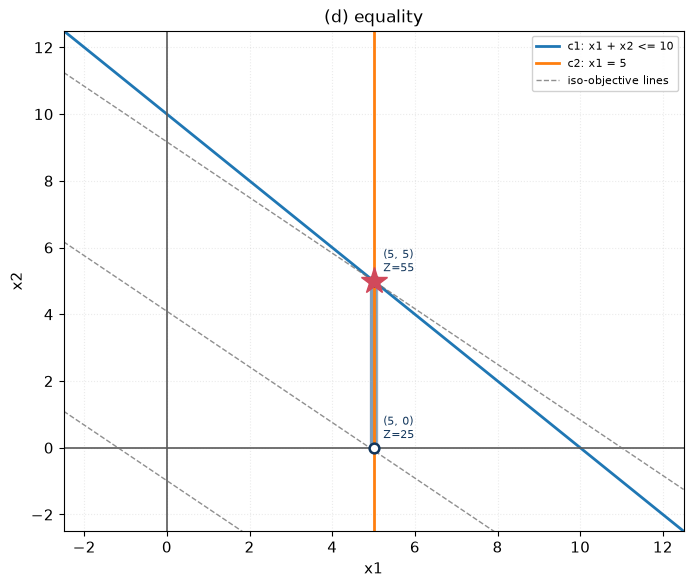

In [24]:
PRACTICE = {
 "(a) unbounded?": """
Maximize
 Z: 6 x1 - 2 x2
Subject To
 c1: x1 - x2 <= 1
 c2: 3 x1 - x2 <= 6
End""",
 "(b) free variables": """
Maximize
 Z: 5 x1 + 6 x2
Subject To
 c1: x1 - 2 x2 >= 1
 c2: -2 x1 + 3 x2 >= 2
Bounds
 x1 free
 x2 free
End""",
 "(c) infeasible?": """
Maximize
 Z: 3 x1 + 2 x2
Subject To
 c1: 2 x1 + x2 <= 2
 c2: 3 x1 + x2 >= 12
End""",
 "(d) equality": """
Maximize
 Z: 5 x1 + 6 x2
Subject To
 c1: x1 + x2 <= 10
 c2: x1 = 5
End""",
}

for name, txt in PRACTICE.items():
    m = parse_lp(txt)
    r = solve_lp(m)
    print(f"\n{'='*64}\n{name}\n{'-'*64}")
    print(m)
    print()
    print(r)
    plot_lp(m, r, title=name)
    plt.show()

---
## Part 6 — The solver: give it an `.lp` file, get the graphical solution

This is the part you will reuse. Point `solve_lp_file` at any `.lp` file holding a
two-variable linear program and it will

* echo the model back in ordinary algebra, so you can check the parse,
* list every corner point with its objective value,
* report the status — optimal / multiple optima / infeasible / unbounded,
* and draw the full graphical solution.

The next cell writes a set of `.lp` files into the working directory (they are also shipped
alongside this notebook, so this is only a safety net — re-run it any time you want the
originals back).

In [25]:
SAMPLE_LP_FILES = {
 "sample_lp.lp": "\\ ===========================================================================\n\\  sample_lp.lp  --  the product-mix problem of the lecture\n\\\n\\  An electronics manufacturer makes DVD players (x1) and mobile phones (x2).\n\\  Each DVD player needs 4 hours of electronic time and 2 hours of assembly\n\\  and earns $7 profit; each mobile phone needs 3 and 1 hours and earns $5.\n\\  240 hours of electronic time and 100 hours of assembly are available.\n\\\n\\  Expected answer:  x1 = 30, x2 = 40, Z = 410\n\\\n\\  FORMAT NOTES\n\\    * lines beginning with a backslash are comments\n\\    * sections: Maximize | Minimize , Subject To , Bounds , Free , End\n\\    * operators: <= >= =   (also =< => < >)\n\\    * every variable is >= 0 unless you say otherwise in Bounds / Free\n\\    * name a constraint by prefixing it with  name:\n\\ ===========================================================================\n\nMaximize\n profit: 7 x1 + 5 x2\n\nSubject To\n electronics: 4 x1 + 3 x2 <= 240\n assembly:    2 x1 + 1 x2 <= 100\n\nBounds\n x1 >= 0\n x2 >= 0\n\nEnd\n",
 "lp_examples/pottery.lp": "\\ Beaver Creek Pottery Company -- maximisation\n\\ x1 = bowls per day, x2 = mugs per day\n\\ Expected: x1 = 24, x2 = 8, Z = 1360\nMaximize\n Z: 40 x1 + 50 x2\nSubject To\n labour: 1 x1 + 2 x2 <= 40\n clay:   4 x1 + 3 x2 <= 120\nEnd\n",
 "lp_examples/photo_chemicals.lp": "\\ Photo-developing chemicals -- minimisation with >= constraints\n\\ x1 = tons of black-and-white chemical, x2 = tons of colour chemical\n\\ Expected: x1 = 40, x2 = 20, Z = 160000\nMinimize\n cost: 2500 x1 + 3000 x2\nSubject To\n bw_requirement:     x1 >= 30\n colour_requirement: x2 >= 20\n total_tonnage:      x1 + x2 >= 60\nEnd\n",
 "lp_examples/airline.lp": "\\ Airline flight planning -- maximisation\n\\ x1 = daily flights to Rome, x2 = daily flights to Dublin\n\\ Expected: x1 = 6, x2 = 6, Z = 27000\nMaximize\n Z: 2500 x1 + 2000 x2\nSubject To\n gate:   x1 + x2 <= 12\n labour: 15 x1 + 10 x2 <= 150\n market: x1 <= 9\nEnd\n",
 "lp_examples/fertilizer.lp": "\\ Fertilizer blending -- minimisation\n\\ x1 = bags of Super-Gro, x2 = bags of Crop-Quick\n\\ Expected: x1 = 0, x2 = 8, Z = 24\nMinimize\n Z: 6 x1 + 3 x2\nSubject To\n nitrogen:  2 x1 + 4 x2 >= 16\n phosphate: 4 x1 + 3 x2 >= 24\nEnd\n",
 "lp_examples/hotdog_mixture.lp": "\\ Hot-dog mixture -- blending, with an EQUALITY and a RATIO constraint\n\\ x1 = kg of chicken, x2 = kg of beef, 1 ton batch\n\\ the ratio  x1/x2 >= 2/1  is written linearly as  x1 - 2 x2 >= 0\n\\ Expected: x1 = 800, x2 = 200, Z = 3400\nMinimize\n Z: 3 x1 + 5 x2\nSubject To\n batch_size:      x1 + x2 = 1000\n chicken_minimum: x1 >= 500\n beef_minimum:    x2 >= 200\n ratio_2_to_1:    x1 - 2 x2 >= 0\nEnd\n",
 "lp_examples/multiple_optima.lp": "\\ Multiple optimal solutions: the objective is parallel to the clay constraint\n\\ Expected: every point of the segment (30,0)-(24,8) is optimal, Z = 1200\nMaximize\n Z: 40 x1 + 30 x2\nSubject To\n labour: x1 + 2 x2 <= 40\n clay:   4 x1 + 3 x2 <= 120\nEnd\n",
 "lp_examples/infeasible.lp": "\\ Infeasible: x1 >= 4 and x2 >= 6 force 4x1 + 2x2 >= 28, which cannot be <= 8\nMaximize\n Z: 5 x1 + 3 x2\nSubject To\n c1: 4 x1 + 2 x2 <= 8\n c2: x1 >= 4\n c3: x2 >= 6\nEnd\n",
 "lp_examples/unbounded.lp": "\\ Unbounded: nothing limits x1 from above and every unit adds 4 to Z\nMaximize\n Z: 4 x1 + 2 x2\nSubject To\n c1: x1 >= 4\n c2: x2 <= 2\nEnd\n",
 "lp_examples/free_variables.lp": "\\ Variables unrestricted in sign -- the optimum lies in the third quadrant\n\\ Expected: x1 = -7, x2 = -4, Z = -59\nMaximize\n Z: 5 x1 + 6 x2\nSubject To\n c1: x1 - 2 x2 >= 1\n c2: -2 x1 + 3 x2 >= 2\nBounds\n x1 free\n x2 free\nEnd\n",
 "lp_examples/bounded_box.lp": "\\ Upper bounds on the variables, written in the Bounds section\n\\ Expected: x1 = 8, x2 = 4, Z = 64\nMaximize\n Z: 6 x1 + 4 x2\nSubject To\n c1: x1 + x2 <= 12\n c2: 2 x1 + x2 <= 20\nBounds\n 0 <= x1 <= 8\n 0 <= x2 <= 9\nEnd\n"
}

import os, pathlib

def write_sample_lp_files(folder="."):
    folder = pathlib.Path(folder)
    for name, text in SAMPLE_LP_FILES.items():
        p = folder / name
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text(text)
    print(f"{len(SAMPLE_LP_FILES)} .lp files written under {folder.resolve()}")
    for name in SAMPLE_LP_FILES:
        print("   ", name)

write_sample_lp_files()

11 .lp files written under C:\Users\islam\Documents\GitHub\IME312_OpearationsResearch1\Fall2026\Lecture2
    sample_lp.lp
    lp_examples/pottery.lp
    lp_examples/photo_chemicals.lp
    lp_examples/airline.lp
    lp_examples/fertilizer.lp
    lp_examples/hotdog_mixture.lp
    lp_examples/multiple_optima.lp
    lp_examples/infeasible.lp
    lp_examples/unbounded.lp
    lp_examples/free_variables.lp
    lp_examples/bounded_box.lp


\ ===========================================================================
\  sample_lp.lp  --  the product-mix problem of the lecture
\
\  An electronics manufacturer makes DVD players (x1) and mobile phones (x2).
\  Each DVD player needs 4 hours of electronic time and 2 hours of assembly
\  and earns $7 profit; each mobile phone needs 3 and 1 hours and earns $5.
\  240 hours of electronic time and 100 hours of assembly are available.
\
\  Expected answer:  x1 = 30, x2 = 40, Z = 410
\
\  FORMAT NOTES
\    * lines beginning with a backslash are comments
\    * sections: Maximize | Minimize , Subject To , Bounds , Free , End
\    * operators: <= >= =   (also =< => < >)
\    * every variable is >= 0 unless you say otherwise in Bounds / Free
\    * name a constraint by prefixing it with  name:
\ ===========================================================================

Maximize
 profit: 7 x1 + 5 x2

Subject To
 electronics: 4 x1 + 3 x2 <= 240
 assembly:    2 x1 + 1 x2 <= 100

Bounds


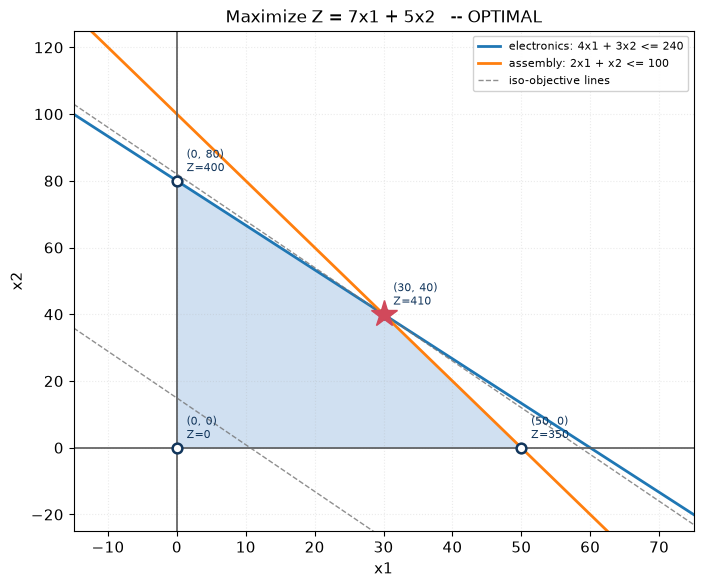

In [26]:
def solve_lp_file(path, show_file=False, **plot_kw):
    """Parse an .lp file, solve it by the corner-point method, and plot it."""
    text = open(path).read()
    if show_file:
        print(text)
        print("=" * 72)
    model = parse_lp(text)
    print(f"FILE: {path}\n")
    print("PARSED MODEL")
    print("-" * 72)
    print(model)

    if model.n_vars != 2:
        print(f"\nThis model has {model.n_vars} variables ({', '.join(model.var_order)}). "
              "The graphical method needs exactly 2 — nothing to draw.")
        return model, None

    result = solve_lp(model)
    print("\nSOLUTION")
    print("-" * 72)
    print(result)

    tbl = result.corner_table()
    if tbl is not None and len(tbl):
        print("\nCORNER POINTS")
        print("-" * 72)
        print(tbl.to_string(index=False))

    plot_lp(model, result, **plot_kw)
    plt.show()
    return model, result


model, result = solve_lp_file("sample_lp.lp", show_file=True)

### 6.1 Pick any of the shipped examples

If `ipywidgets` is installed this is a dropdown; otherwise the cell solves them all in turn.

In [27]:
import glob, os

lp_files = sorted(glob.glob("*.lp") + glob.glob("lp_examples/*.lp"))

if HAS_WIDGETS:
    @interact(lp_file=Dropdown(options=lp_files, value="sample_lp.lp",
                               description="LP file:",
                               layout=Layout(width="60%")),
              show_source=False)
    def _pick(lp_file, show_source):
        solve_lp_file(lp_file, show_file=show_source)
else:
    for f in lp_files:
        print("\n" + "#" * 72)
        solve_lp_file(f)

interactive(children=(Dropdown(description='LP file:', index=10, layout=Layout(width='60%'), options=('lp_exam…

### 6.2 Type or paste your own LP

Edit the text below and press **Solve**. The same text can be saved to a file with the
button next to it, and then re-opened from the dropdown above.

In [28]:
DEFAULT_LP = """\\ my problem
Maximize
 Z: 3 x + 2 y
Subject To
 c1: 2 x + y <= 18
 c2: 2 x + 3 y <= 42
 c3: 3 x + y <= 24
End
"""

if HAS_WIDGETS:
    box = Textarea(value=DEFAULT_LP, layout=Layout(width="100%", height="230px"))
    fname = Textarea(value="my_problem.lp", layout=Layout(width="220px", height="30px"))
    run_btn, save_btn = Button(description="Solve", button_style="primary"), \
                        Button(description="Save to file")
    out = Output()

    def _run(_):
        out.clear_output()
        with out:
            try:
                m = parse_lp(box.value)
                print("PARSED MODEL\n" + "-"*72)
                print(m)
                if m.n_vars != 2:
                    print(f"\nNeed exactly 2 variables to draw; this one has {m.n_vars}.")
                    return
                r = solve_lp(m)
                print("\nSOLUTION\n" + "-"*72)
                print(r)
                t = r.corner_table()
                if t is not None and len(t):
                    print("\nCORNER POINTS\n" + "-"*72)
                    print(t.to_string(index=False))
                plot_lp(m, r); plt.show()
            except Exception as e:
                print("Could not parse / solve:", type(e).__name__, e)

    def _save(_):
        with open(fname.value.strip(), "w") as f:
            f.write(box.value)
        with out:
            print(f"saved to {os.path.abspath(fname.value.strip())}")

    run_btn.on_click(_run); save_btn.on_click(_save)
    display(VBox([box, HBox([run_btn, save_btn, fname]), out]))
    _run(None)
else:
    m, r = parse_lp(DEFAULT_LP), None
    print(m); r = solve_lp(m); print("\n", r)
    plot_lp(m, r); plt.show()

### 6.3 Solve every shipped example at once — a regression check

The expected answers are written in the comments at the top of each file. This cell checks
the solver reproduces the lecture's results.

In [29]:
EXPECTED = {
 "sample_lp.lp":                   ("optimal", (30, 40), 410),
 "lp_examples/pottery.lp":         ("optimal", (24, 8), 1360),
 "lp_examples/photo_chemicals.lp": ("optimal", (40, 20), 160000),
 "lp_examples/airline.lp":         ("optimal", (6, 6), 27000),
 "lp_examples/fertilizer.lp":      ("optimal", (0, 8), 24),
 "lp_examples/hotdog_mixture.lp":  ("optimal", (800, 200), 3400),
 "lp_examples/multiple_optima.lp": ("optimal", None, 1200),
 "lp_examples/infeasible.lp":      ("infeasible", None, None),
 "lp_examples/unbounded.lp":       ("unbounded", None, None),
 "lp_examples/free_variables.lp":  ("optimal", (-7, -4), -59),
 "lp_examples/bounded_box.lp":     ("optimal", (8, 4), 64),
}

print(f"{'file':<34}{'status':<13}{'Z':>12}   check")
print("-" * 76)
for f, (st, xy, z) in EXPECTED.items():
    r = solve_lp(load_lp(f))
    ok = r.status == st and (z is None or abs(r.z - z) < 1e-6)
    print(f"{f:<34}{r.status:<13}{('' if r.z is None else f'{r.z:,.4g}'):>12}   "
          f"{'PASS' if ok else 'FAIL'}"
          + ("  (multiple optima)" if r.multiple else ""))

file                              status                  Z   check
----------------------------------------------------------------------------
sample_lp.lp                      optimal               410   PASS
lp_examples/pottery.lp            optimal             1,360   PASS
lp_examples/photo_chemicals.lp    optimal           1.6e+05   PASS
lp_examples/airline.lp            optimal           2.7e+04   PASS
lp_examples/fertilizer.lp         optimal                24   PASS
lp_examples/hotdog_mixture.lp     optimal             3,400   PASS
lp_examples/multiple_optima.lp    optimal             1,200   PASS  (multiple optima)
lp_examples/infeasible.lp         infeasible                  PASS
lp_examples/unbounded.lp          unbounded                   PASS
lp_examples/free_variables.lp     optimal               -59   PASS
lp_examples/bounded_box.lp        optimal                64   PASS


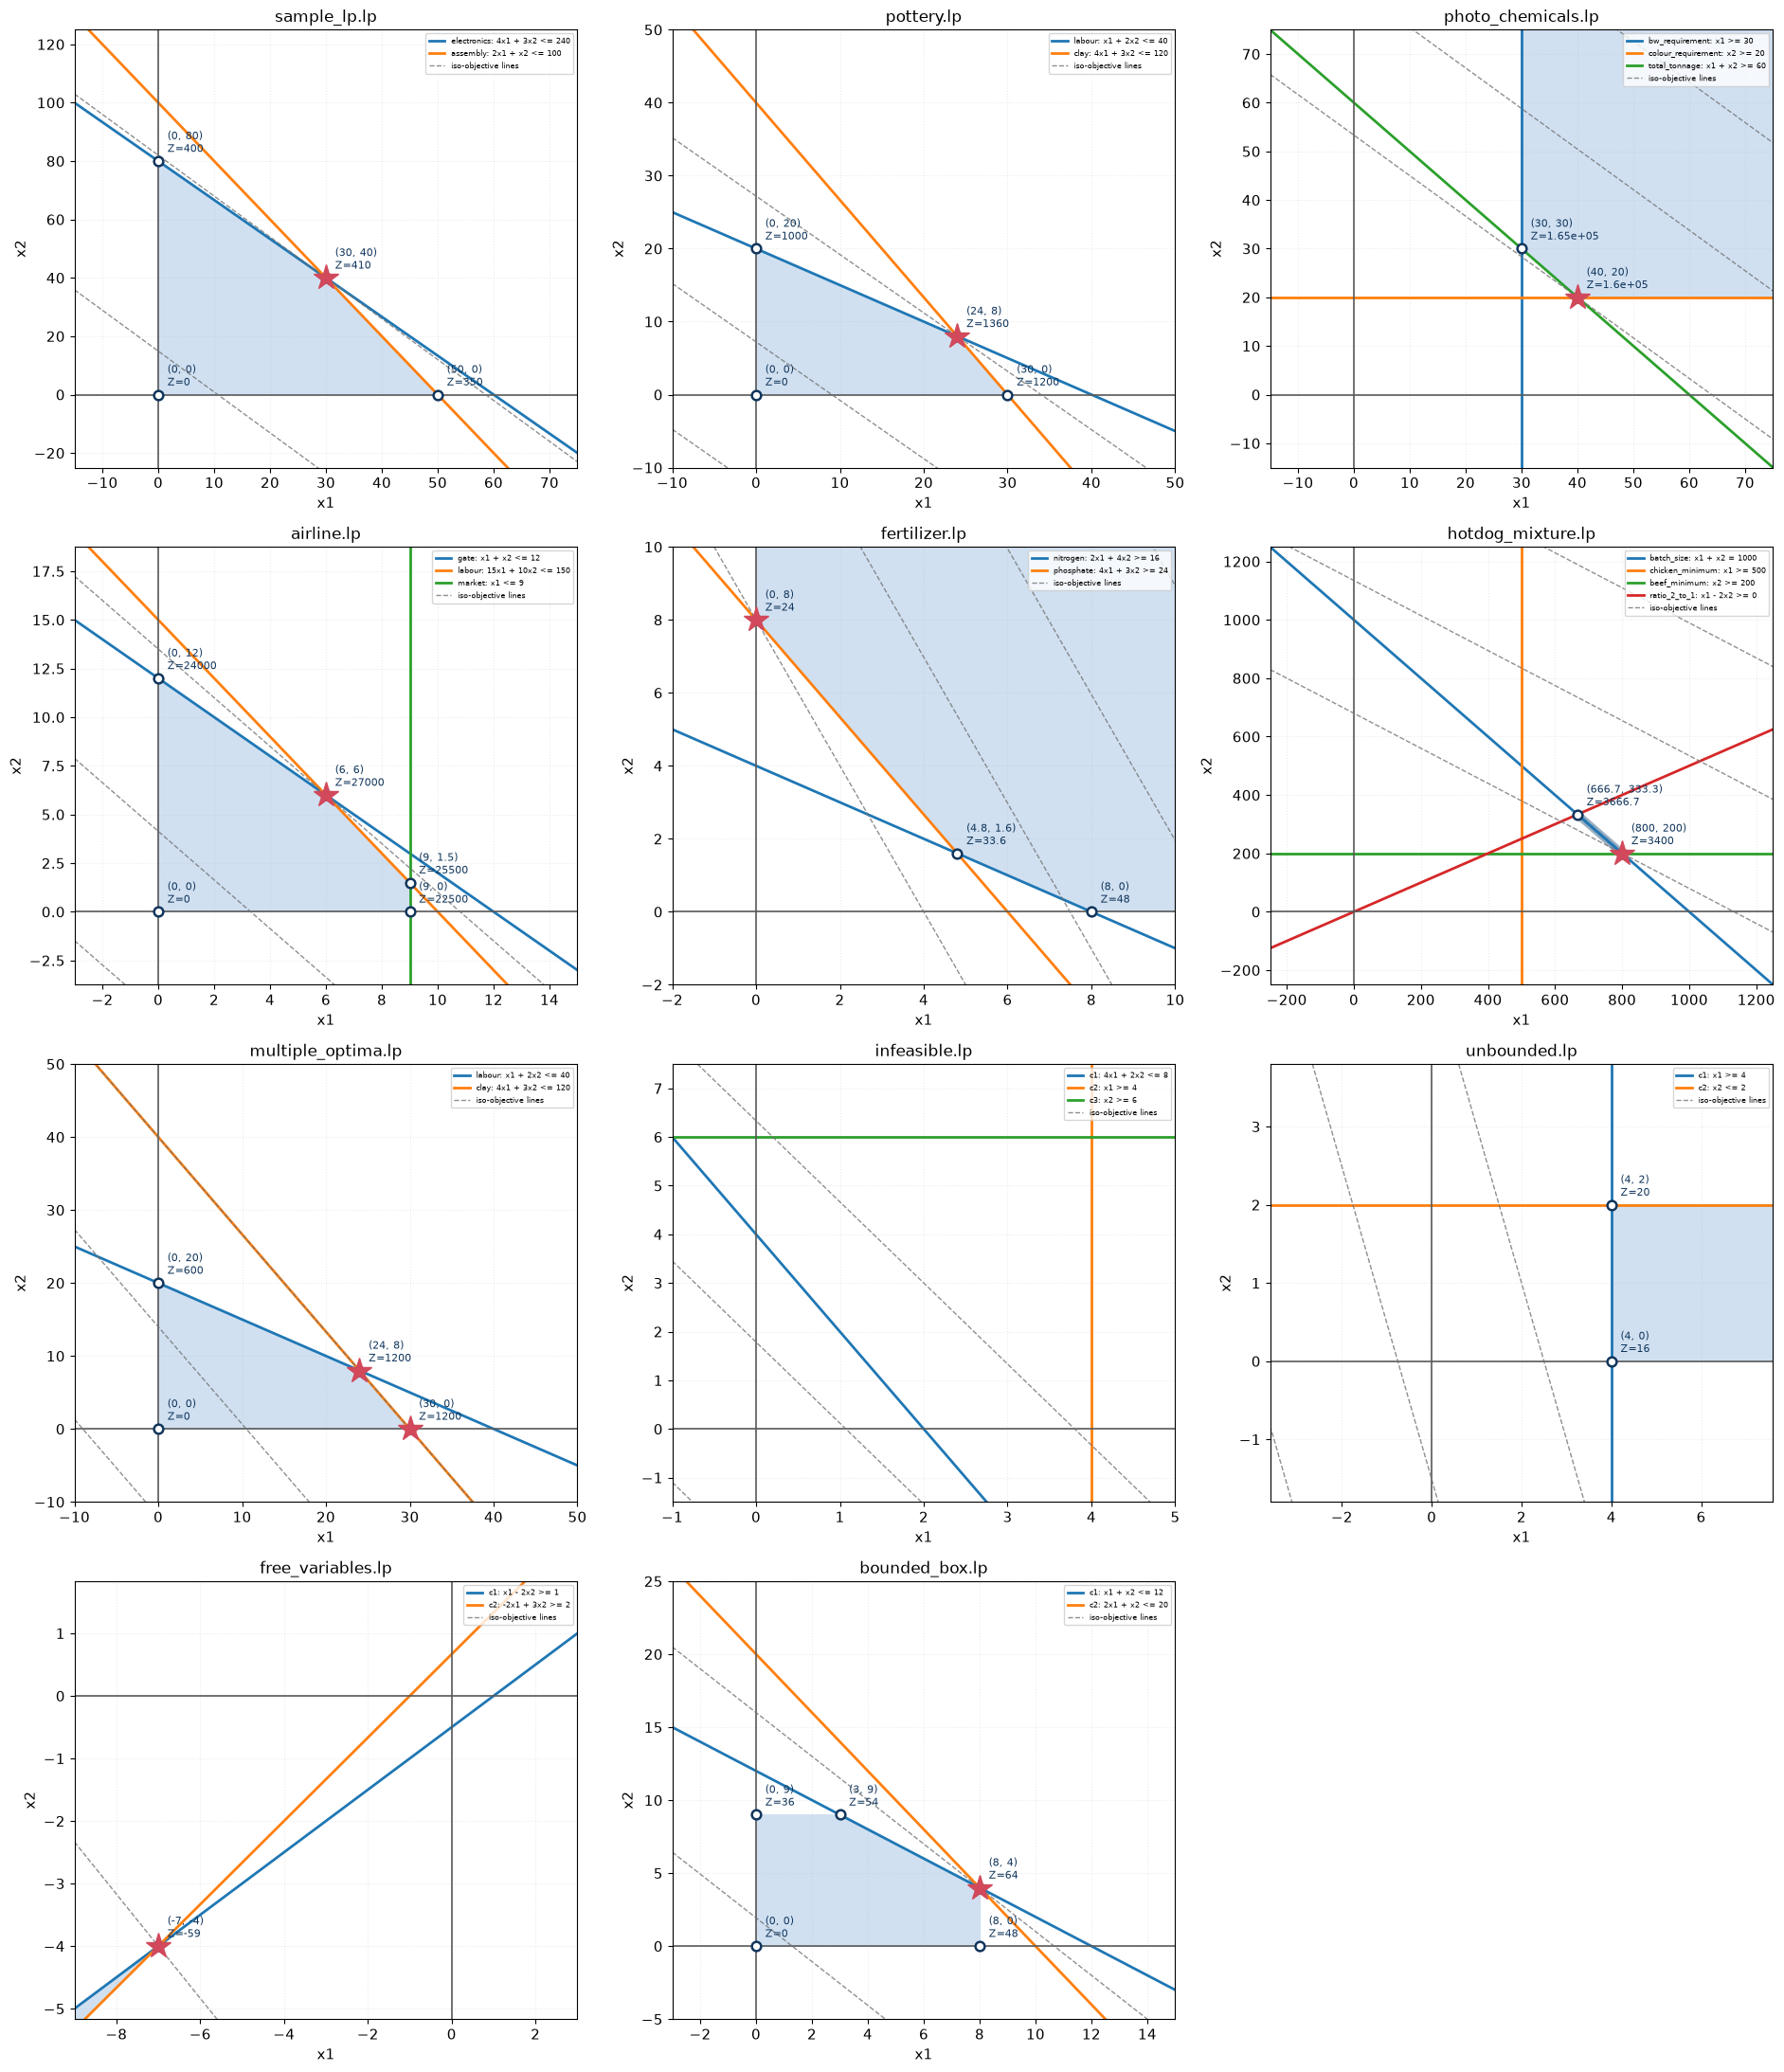

In [30]:
# a gallery of all of them
fig, axes = plt.subplots(4, 3, figsize=(19, 22))
for ax, f in zip(axes.ravel(), EXPECTED):
    m = load_lp(f)
    plot_lp(m, solve_lp(m), ax=ax, title=os.path.basename(f))
    ax.legend(fontsize=6, loc="upper right")
for ax in axes.ravel()[len(EXPECTED):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

---
## Part 7 — Exercises

Write each of these as an `.lp` file (use the text box in §6.2, save it, then solve it).

1. **Furniture.** A workshop makes tables and chairs. A table needs 3 hours of carpentry and
   1 hour of finishing; a chair needs 2 hours of carpentry and 2 hours of finishing.
   240 carpentry hours and 200 finishing hours are available per week. A table earns \$70
   profit, a chair \$50. Find the weekly production plan that maximises profit.
   *Check: 60 tables, 30 chairs, \$5,700.*

2. **Diet.** Two foods cost \$0.60 and \$1.00 per unit. Food A supplies 400 calories and
   3 g of protein per unit; food B supplies 200 calories and 10 g of protein. A meal must
   supply at least 2,000 calories and at least 30 g of protein. Minimise cost.

3. **Modify the airline problem.** Raise the profit per Dublin flight until the optimum
   moves away from (6, 6). At what value does it jump, and where does it jump to?
   *(Hint: use the sensitivity slider in §3.6, then confirm with an `.lp` file.)*

4. **Make one infeasible on purpose.** Take `lp_examples/pottery.lp` and add a constraint
   that makes the region empty. Then add a different one that makes it unbounded — note that
   you have to *remove* a constraint instead, and think about why.

5. **Force multiple optima.** In `lp_examples/pottery.lp`, change the objective coefficients
   so that the iso-profit line is parallel to the labour constraint $x_1 + 2x_2 \le 40$.
   What ratio $c_1 : c_2$ do you need? Verify that the solver reports multiple optima.

---

### What to take away

* The **formulation** — variables, objective, constraints, non-negativity — is the part that
  requires judgement. Check the units of every constraint.
* With two variables, the feasible region is a **convex polygon** (possibly unbounded), and
  the optimum is always at a **corner point**. That is why we can search finitely many
  points instead of infinitely many.
* The **iso-profit line** method and the **corner-point** method are two ways of exploiting
  the same fact; the corner-point method is the one that generalises — it becomes the
  simplex method when there are more than two variables.
* **Infeasible** and **unbounded** outcomes are messages about the *model*, not the maths:
  something has been over-promised, or a real-world limit has been left out.

---

*Based on the lecture "LP Formulation and Graphical Solution" by Dr. Islam Ali.*